# Project: Detecting Parkinson's Disease from Short Speech Recordings using SpeechBrain

**Goal:** To develop and evaluate neural network models within the SpeechBrain framework for detecting the presence of Parkinson's disease (PD) from short speech recordings, aiming for the highest possible accuracy.



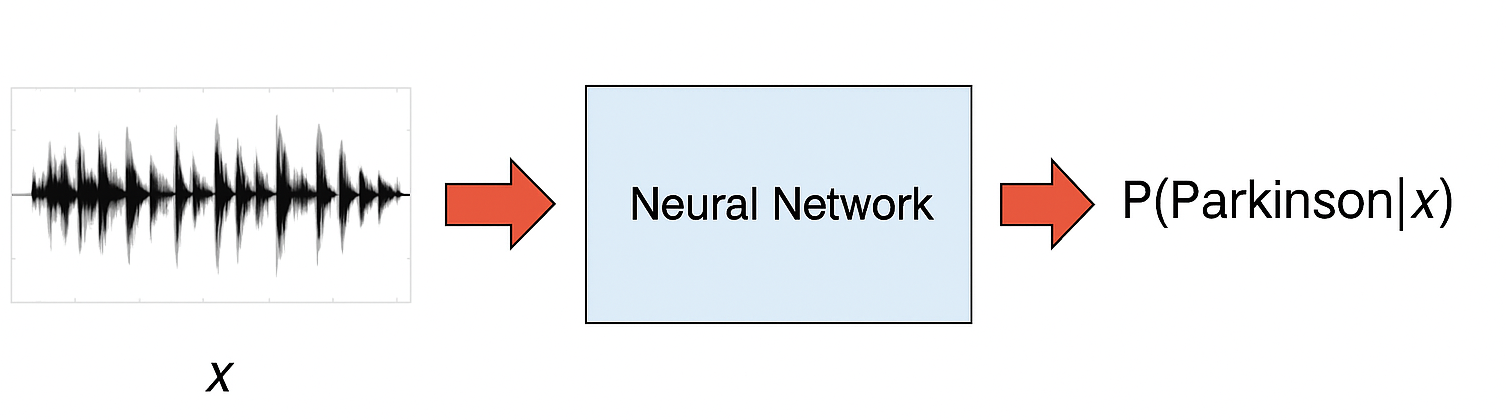

**Approach:** This project will start by implementing and evaluating standard speech models like X-vectors and ECAPA-TDNN. Subsequently, we will explore fine-tuning powerful pre-trained self-supervised models such as Wav2Vec2 and HuBERT. Finally, we will investigate strategies like data augmentation and transfer learning to further optimize performance. The primary dataset used is the [Italian Parkinson's Voice and Speech dataset](https://huggingface.co/datasets/birgermoell/Italian_Parkinsons_Voice_and_Speech).


## ***Data Preparation***

### Script Summary: `prepare_pd_data.py`

This Python script automates the preprocessing steps for the "Italian Parkinson's Voice and Speech" dataset (`birgermoell/Italian_Parkinsons_Voice_and_Speech`), preparing it for machine learning tasks.

**Key Functions:**

* **Data Acquisition & Splitting:** Loads the dataset from Hugging Face and divides it into reproducible `train`, `validation`, and `test` sets (using a fixed seed).
* **Subsampling:** Optionally processes only a fraction of the data using the `--subset` command-line argument.
* **Audio Normalization:** Converts each audio file to a PyTorch tensor, resamples it to **16,000 Hz**, and ensures it is **mono** channel.
* **Condition Labeling:** Infers the condition ('PD' or 'healthy') from the original file path and assigns this label.
* **Output Generation:**
    * Saves the processed (16kHz, mono) audio as `.wav` files in structured output folders (controlled by `--out_dir`).
    * Creates `.csv` manifest files for each split (named with a customizable `--tag`). These CSVs contain `ID`, `path`, `duration`, and the inferred `language` (condition), ready for model training pipelines.

In essence, the script transforms the raw dataset into clean, uniformly formatted audio files and associated metadata CSVs.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


In [ ]:
%%file prepare_pd_data.py
#!/usr/bin/env python3

"""
Prepare the Italian Parkinson's dataset.

Downloads, splits, subsamples, resamples audio to 16kHz mono, and generates CSV manifests.

Example
-------
$ python prepare_pd_data.py --subset 0.5 --tag 50pct
Generates:
    train_50pct.csv, validation_50pct.csv, test_50pct.csv
and saves resampled/mono WAV files under processed_audio_pd/{train,validation,test}
"""
import argparse, csv, logging, os, sys
from pathlib import Path

import numpy as np
import torch
import torchaudio
from datasets import load_dataset, DatasetDict, Audio


TARGET_SR = 16_000           # Target sample rate for processed audio
PROCESSED_ROOT = "processed_audio_pd" # Directory to save processed files

# Configure basic logging
logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s: %(message)s")


def infer_condition_from_path(path: str) -> str:
    """Derive 'healthy' / 'PD' label from original file path."""
    plow = path.lower()
    if "healthy" in plow:
        return "healthy"
    if "parkinson" in plow or "pd" in plow:
        return "PD"
    # Log a warning if condition cannot be inferred
    logging.warning("Could not infer condition for %s → 'unknown'", path)
    return "unknown"


def resample_and_mono(tensor: torch.Tensor, orig_sr: int) -> torch.Tensor:
    """Convert audio tensor to mono and resample to TARGET_SR."""
    if tensor.ndim == 1:
        tensor = tensor.unsqueeze(0)
    if orig_sr != TARGET_SR:
        tensor = torchaudio.transforms.Resample(
            orig_freq=orig_sr, new_freq=TARGET_SR)(tensor)
    if tensor.shape[0] > 1:
        tensor = tensor.mean(dim=0, keepdim=True)
    return tensor


def dataset_to_csv(split_ds, split_name: str,
                   subset_tag: str, out_dir: Path) -> None:
    """Process dataset split, save audio, and write CSV manifest."""
    # Create output directory for WAV files
    wav_dir = out_dir / split_name
    wav_dir.mkdir(parents=True, exist_ok=True)

    # Open CSV file for writing
    csv_path = Path(f"{split_name}_{subset_tag}.csv")
    with csv_path.open("w", newline="", encoding="utf‑8") as fp:
        # Setup CSV writer
        writer = csv.DictWriter(fp,
                                fieldnames=["ID", "path", "duration", "language"])
        writer.writeheader()

        kept = skipped = 0

        for i, rec in enumerate(split_ds):
            audio = rec.get("audio")
            if audio is None:
                skipped += 1
                continue

            arr, sr = audio.get("array"), audio.get("sampling_rate")
            path_hint = audio.get("path", f"{split_name}_{i}.wav")

            # Convert audio array to torch tensor
            if isinstance(arr, np.ndarray):
                tensor = torch.from_numpy(arr)
            elif isinstance(arr, torch.Tensor):
                tensor = arr
            else:                                 # Handle list, etc. → tensor
                tensor = torch.tensor(arr)

            if tensor.numel() == 0: # Skip empty tensors
                skipped += 1
                continue

            # Resample and convert to mono
            tensor = resample_and_mono(tensor.float(), sr)
            uid = f"{split_name}_{kept}"
            wav_path = wav_dir / f"{uid}.wav"
            # Save processed audio to WAV file
            torchaudio.save(wav_path.as_posix(), tensor, TARGET_SR)

            # Calculate duration and write CSV row
            duration = tensor.shape[1] / TARGET_SR
            writer.writerow(dict(
                ID=uid, path=wav_path.as_posix(),
                duration=f"{duration:.5f}",
                language=infer_condition_from_path(path_hint)
            ))
            kept += 1

        # Log summary for the split
        logging.info("%s → %s (kept %d, skipped %d)",
                     split_name, csv_path, kept, skipped)


def main(subset_fraction: float, tag: str, out_root: str):
    # Load dataset
    ds = load_dataset("birgermoell/Italian_Parkinsons_Voice_and_Speech")
    full_ds = ds["train"] if "train" in ds else ds

    # ---------- train / val / test splitting ---------- #
    # Perform standard split if dataset is not already split
    if not isinstance(full_ds, DatasetDict):
        # 80/10/10 split roughly (80% train, then that 80% split 10% for val)
        split = full_ds.train_test_split(test_size=0.2, seed=42, shuffle=True)
        train_val = split["train"].train_test_split(
            test_size=0.1, seed=42, shuffle=True) # Split train further for validation
        full_ds = DatasetDict(train=train_val["train"],
                              validation=train_val["test"],
                              test=split["test"])

    # ---------- sub‑sampling ---------- #
    # Apply subsampling to each split
    subset_ds = DatasetDict()
    for split in full_ds.keys():
        n = len(full_ds[split])
        m = max(1, int(n * subset_fraction)) if subset_fraction > 0 else 0
        subset_ds[split] = full_ds[split].select(range(m)) # Select subset of samples
        logging.info("%s: kept %d / %d samples (%.1f%%)",
                     split, m, n, 100 * subset_fraction)

    # ---------- process & write CSVs ---------- #
    # Prepare output directory and process each split
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    for split in ["train", "validation", "test"]:
        dataset_to_csv(subset_ds[split], split, tag, out_root) # Process split and write CSV


if __name__ == "__main__":
    # Setup argument parser
    parser = argparse.ArgumentParser(
        description="Create resampled WAVs and CSV manifests.")
    # Define command line arguments
    parser.add_argument("--subset", type=float, default=1.0,
                        help="Fraction of each split to keep (e.g. 0.5).")
    parser.add_argument("--tag", default="full",
                        help="Label embedded in CSV filenames.")
    parser.add_argument("--out_dir", default=PROCESSED_ROOT,
                        help="Root folder for cleaned WAV files and manifests.")
    # Parse arguments, ignoring unknown ones (e.g., from notebooks)
    args, _ = parser.parse_known_args(sys.argv[1:])
    # Run the main data processing function
    main(args.subset, args.tag, args.out_dir)

Writing prepare_pd_data.py


**Purpose:** This cell executes the data preparation script (`prepare_pd_data.py`) to process the **entire dataset** (100%).

In [ ]:
!python prepare_pd_data.py --subset 1 --tag 100pct

README.md: 100% 1.44k/1.44k [00:00<00:00, 8.94MB/s]
Resolving data files: 100% 833/833 [00:00<00:00, 939.27it/s]
B1AMULCAAS94M100120171016.wav:   0% 0.00/1.28M [00:00<?, ?B/s]

B2LBULCAAS94M100120171015.wav:   0% 0.00/1.25M [00:00<?, ?B/s]


PR1LBULCAAS94M100120171015..wav:   0% 0.00/1.47M [00:00<?, ?B/s]



B2LBULCAAS94M100120171016.wav:   0% 0.00/1.28M [00:00<?, ?B/s]




B1LBULCAAS94M100120171015.wav:   0% 0.00/1.23M [00:00<?, ?B/s]





PR1LBULCAAS94M100120171017.wav:   0% 0.00/1.58M [00:00<?, ?B/s]






PR1LBULCAAS94M100120171056.wav:   0% 0.00/1.36M [00:00<?, ?B/s]







B2LBULCAAS94M100120171015.wav: 100% 1.25M/1.25M [00:00<00:00, 29.7MB/s]
B1AMULCAAS94M100120171016.wav: 100% 1.28M/1.28M [00:00<00:00, 22.8MB/s]

B2LBULCAAS94M100120171053.wav:   0% 0.00/1.30M [00:00<?, ?B/s]

B1LBULCAAS94M100120171053.wav:   0% 0.00/1.30M [00:00<?, ?B/s]








B2LBULCAAS94M100120171016.wav: 100% 1.28M/1.28M [00:00<00:00, 34.6MB/s]
PR1LBULCAAS94M100120171015..wav: 100% 1.47M/1.47M [00:00<00:00

## ***Install SpeechBrain from GitHub Source***

**Purpose:** This cell clones the latest version of the SpeechBrain library directly from its GitHub repository.

In [ ]:
%%capture
!git clone https://github.com/speechbrain/speechbrain.git
%cd speechbrain
!pip install -r requirements.txt
!pip install .
%cd ..

.
.
.
.
.
.
.
.







> ## **Experiment Phase 1: Traning Xvectors Model on a 100% Data Subset**

## ***1.1 Experiment: Training X-vectors on Full Parkinson's Dataset (100%)***

**Goal:** Configure and train the X-vector based model for Parkinson's disease detection using the complete (100%) processed dataset.


---


### 1.1.1 Hyperparameters for X-vector (100% Data)

### Configuration Summary: `xvectors.yaml`

This YAML file sets up a SpeechBrain experiment to train an **X-vector model** for binary **Parkinson's Disease classification**.

* **Key Settings:** Defines data/output paths, seed, epochs (20), batch size (8), learning rate schedule (Adam optimizer, linear annealing).
* **Model & Features:** Specifies the X-vector architecture (`embedding_model`), a linear classifier, Fbank features (40 mels), and sentence-level normalization.
* **Utilities:** Includes NLL loss, checkpointing configuration, and a categorical label encoder.

In [ ]:
%%file xvectors.yaml
# #################################
# Hparams file for training X-vector embeddings for
# Parkinson's Disease detection.
# Adapted from an ECAPA-TDNN LID recipe.
# #################################

seed: 1986
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]
data_folder: !PLACEHOLDER
output_folder: !ref results/Xvector_PD/<seed>
save_folder: !ref <output_folder>/save
train_log: !ref <output_folder>/train_log.txt

# Direct paths to your prepared CSV files
train_csv: !PLACEHOLDER
dev_csv: !PLACEHOLDER
test_csv: !PLACEHOLDER

# Data preparation is already done
skip_prep: True

# Data for augmentation (Optional - kept from original recipe)
NOISE_DATASET_URL: https://www.dropbox.com/scl/fi/a09pj97s5ifan81dqhi4n/noises.zip?rlkey=j8b0n9kdjdr32o1f06t0cw5b7&dl=1
RIR_DATASET_URL: https://www.dropbox.com/scl/fi/linhy77c36mu10965a836/RIRs.zip?rlkey=pg9cu8vrpn2u173vhiqyu743u&dl=1
# Set appropriate paths for downloaded noise/rir data if using augmentation
data_folder_noise: !ref <data_folder>/augmentation_data/noise # Example path
data_folder_rir: !ref <data_folder>/augmentation_data/rir   # Example path
noise_annotation: !ref <save_folder>/noise.csv # Will be created
rir_annotation: !ref <save_folder>/rir.csv     # Will be created

# The train logger writes training statistics to a file, as well as stdout.
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log>

error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch

####################### Training Parameters ####################################
sample_rate: 16000
number_of_epochs: 20
batch_size: 8
n_classes: 2 # Binary classification (PD vs Healthy)
emb_dim: 128 # Target embedding dimension

# Feature parameters
n_mels: 40

# Dataloaders
num_workers: 4
drop_last: True # Might be useful especially if using augmentations
train_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: !ref <drop_last>
  shuffle: True

valid_dataloader_options: # Renamed from test_dataloader_options
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False # Usually False for validation/test
  shuffle: False # Usually False for validation/test

test_dataloader_options: # Added for final testing
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False
  shuffle: False



# # Alternatively, disable augmentation:
wav_augment: None

############################## Feature Extraction ##############################

# Feature extraction
compute_features: !new:speechbrain.lobes.features.Fbank
  n_mels: !ref <n_mels>
  sample_rate: !ref <sample_rate>
  # Consider adding frame_length, frame_shift if needed

# Mean and std normalization of the input features
mean_var_norm_input: !new:speechbrain.processing.features.InputNormalization
  norm_type: sentence # Sentence-level MVN is common for x-vectors
  std_norm: False # Or True, experiment

############################## Models ##########################################

# Embedding Model (X-vector)
embedding_model: !new:speechbrain.lobes.models.Xvector.Xvector
  in_channels: !ref <n_mels>         # Fbank dimension (40)
  lin_neurons: !ref <emb_dim>   # Output embedding size (128)
  activation: !name:torch.nn.LeakyReLU # Example activation

# Classifier (Simple Linear Layer)
classifier: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <emb_dim>       # Input embedding size (128)
  n_neurons: !ref <n_classes>      # Output classes (2)
  bias: True

log_softmax_activation: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# The first object passed to the Brain class is this "Epoch Counter"
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

modules:
  compute_features: !ref <compute_features>
  embedding_model: !ref <embedding_model>
  mean_var_norm_input: !ref <mean_var_norm_input>
  classifier: !ref <classifier>
  log_softmax_activation: !ref <log_softmax_activation>

# Loss Function (Negative Log-Likelihood)
compute_cost: !name:speechbrain.nnet.losses.nll_loss


# Learning rates and Optimizer
lr_start: 0.001
lr_final: 0.0001

# Optimizer
opt_class: !name:torch.optim.Adam
  lr: !ref <lr_start>
  weight_decay: 0.000002 # Kept from original recipe, adjust if needed


# Learning Rate Annealing (Linear Decay)
lr_annealing: !new:speechbrain.nnet.schedulers.LinearScheduler
  initial_value: !ref <lr_start>
  final_value: !ref <lr_final>
  epoch_count: !ref <number_of_epochs>

############################## Checkpointing ###################################

# This object is used for saving the state of training
checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder>
  recoverables:
    embedding_model: !ref <embedding_model>
    classifier: !ref <classifier>
    mean_var_norm_input: !ref <mean_var_norm_input> # Normalizer for features
    counter: !ref <epoch_counter>
    # Add label_encoder if you want the checkpointer to save/load it automatically
    # label_encoder: !ref <label_encoder> # Define label_encoder below if using this


############################## Label Encoder ##################################
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Overwriting xvectors.yaml


### 1.1.2 Script Summary: `train_xvector.py`

This Python script (`train_xvector.py`) uses SpeechBrain to train and evaluate an X-vector model for Parkinson's detection, configured by a YAML file.

* **`PD_Detector` (Brain Class):** Manages the training loop, handling feature computation (Fbank+MVN), the forward pass (X-vector + classifier), loss calculation (NLL), logging, LR updates, and checkpoint saving.
* **`dataio_prep` Function:** Loads train/validation/test datasets from CSV files and defines the audio loading and label encoding pipelines using `DynamicItemDataset`.
* **Main Execution:** Parses command-line arguments, loads the YAML config, prepares data via `dataio_prep`, initializes the `PD_Detector`, then runs training (`.fit()`) and final evaluation (`.evaluate()`).

In [ ]:
%%file train_xvector.py
#!/usr/bin/env python3

import os
import sys
import torch
import torchaudio
from hyperpyyaml import load_hyperpyyaml
import logging

import speechbrain as sb
from speechbrain.utils.distributed import run_on_main
from speechbrain.utils.logger import get_logger

"""Recipe for training an X-vector based system for Parkinson's Disease detection.
Adapted from a SpeechBrain LID recipe using ECAPA-TDNN.

To run this recipe:
> python train_pd.py hparams_pd.yaml --data_folder=/path/to/audio --train_csv=train.csv --dev_csv=validation.csv --test_csv=test.csv

Or modify the !PLACEHOLDER values in hparams_pd.yaml directly.

Author
------
Original LID Recipe Authors:
 * Mirco Ravanelli 2021
 * Pavlo Ruban 2021
Adaptation for PD Detection:
 * Gemini 2025
"""

logger = logging.getLogger(__name__)


# Brain class for Parkinson's Disease Detection Training
class PD_Detector(sb.Brain):
    """Class that manages the training loop. Needs implementing."""

    def prepare_features(self, wavs, stage):
        """Prepare the features for computation, including augmentation.

        Arguments
        ---------
        wavs : tuple
            Input signals (tensor) and their relative lengths (tensor).
        stage : sb.Stage
            The current stage of training.

        Returns
        -------
        feats : torch.Tensor
            Computed features.
        lens : torch.Tensor
            The length of the corresponding features.
        """
        wavs, lens = wavs

        feats = self.modules.compute_features(wavs)
        feats = self.modules.mean_var_norm_input(feats, lens)

        return feats, lens

    def compute_forward(self, batch, stage):
        """Runs all the computation of that transforms the input into the
        output probabilities over the N classes.

        Arguments
        ---------
        batch : PaddedBatch
            This batch object contains all the relevant tensors for computation.
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.

        Returns
        -------
        predictions : torch.Tensor
            torch.Tensor that contains the predictions (logits) over the N classes.
        lens : torch.Tensor
            The corresponding relative lengths.
        """
        # We first move the batch to the appropriate device.
        batch = batch.to(self.device)

        # Compute features, embeddings and output
        feats, lens = self.prepare_features(batch.sig, stage)
        embeddings = self.modules.embedding_model(feats)
        # Classifier computes logits
        predictions = self.modules.classifier(embeddings)

        return predictions, lens

    def compute_objectives(self, inputs, batch, stage):
        """Computes the loss given the predicted and targeted outputs.

        Arguments
        ---------
        inputs : tensors
            The output tensors from `compute_forward`.
        batch : PaddedBatch
            This batch object contains all the relevant tensors for computation.
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.

        Returns
        -------
        loss : torch.Tensor
            A one-element tensor used for backpropagating the gradient.
        """
        predictions, lens = inputs

        # Get targets (encoded labels). Ensure "label_encoded" matches output_keys in dataio_prep
        targets = batch.label_encoded.data

        if stage == sb.Stage.TRAIN and hasattr(self.hparams, "wav_augment") and self.hparams.wav_augment is not None:
            original_batch_size = targets.shape[0]
            augmented_batch_size = predictions.shape[0] # predictions is the output after potential augmentation

            # Check if batch size actually increased (augmentation happened and concat_original=True)
            if augmented_batch_size > original_batch_size:
                # Calculate the replication factor dynamically
                multiplier = augmented_batch_size // original_batch_size
                if augmented_batch_size % original_batch_size != 0:
                    # This shouldn't happen with Augmenter's typical behavior, but add a warning
                    logger.warning(f"Augmented batch size ({augmented_batch_size}) is not an even multiple of original batch size ({original_batch_size}). Check augmentation logic.")

                # Replicate targets using the dynamic multiplier
                targets = targets.repeat_interleave(multiplier, dim=0)

        # Apply log_softmax to predictions (logits) before NLL loss
        log_probs = self.modules.log_softmax_activation(predictions)

        # Compute NLL loss
        loss = self.hparams.compute_cost(log_probs, targets, length=lens) # Use lens for potential length normalization/masking if loss supports it

        # Append metrics for evaluation stages
        if stage != sb.Stage.TRAIN:
            # Assuming classification_error metric handles logits correctly
            self.error_metrics.append(batch.id, predictions, targets, lens)

        return loss

    def on_stage_start(self, stage, epoch=None):
        """Gets called at the beginning of each epoch.

        Arguments
        ---------
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.
        epoch : int
            The currently-starting epoch. This is passed
            `None` during the test stage.
        """
        # Set up evaluation-only statistics trackers
        if stage != sb.Stage.TRAIN:
            self.error_metrics = self.hparams.error_stats()

    def on_stage_end(self, stage, stage_loss, epoch=None):
        """Gets called at the end of an epoch.

        Arguments
        ---------
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, sb.Stage.TEST
        stage_loss : float
            The average loss for all of the data processed in this stage.
        epoch : int
            The currently-starting epoch. This is passed
            `None` during the test stage.
        """
        # Store the train loss until the validation stage.
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss

        # Summarize the statistics from the stage for record-keeping.
        else:
            stats = {
                "loss": stage_loss,
                "error": self.error_metrics.summarize("average"),
            }

        if stage == sb.Stage.VALID:
            # Learning rate annealing
            old_lr, new_lr = self.hparams.lr_annealing(epoch)
            sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr)

            # The train_logger writes a summary to stdout and to the logfile.
            self.hparams.train_logger.log_stats(
                {"Epoch": epoch, "LR": old_lr}, # Changed "lr" to "LR" for clarity
                train_stats={"loss": self.train_loss},
                valid_stats=stats,
            )
            self.checkpointer.save_and_keep_only(meta=stats, min_keys=["error"])


        # We also write statistics about test data to stdout and to the logfile.
        if stage == sb.Stage.TEST:
            self.hparams.train_logger.log_stats(
                {"Epoch loaded": self.hparams.epoch_counter.current},
                test_stats=stats,
            )


def dataio_prep(hparams):
    """This function prepares the datasets to be used in the brain class.
    It also defines the data processing pipeline through user-defined functions.
    Assumes that `train.csv`, `validation.csv`, and `test.csv` manifest files
    already exist.

    Arguments
    ---------
    hparams : dict
        This dictionary is loaded from the `hparams_pd.yaml` file, and it includes
        all the hyperparameters needed for dataset construction and loading.

    Returns
    -------
    datasets : dict
        Contains keys "train", "dev", "test" mapping to appropriate DynamicItemDataset objects.
    label_encoder : CategoricalEncoder
        The fitted label encoder.
    """

    # Retrieve or define the label encoder
    label_encoder = hparams["label_encoder"]

    # Define audio pipeline
    @sb.utils.data_pipeline.takes("path")
    @sb.utils.data_pipeline.provides("sig")
    def audio_pipeline(wav_path):
        """Load the signal from the processed wav file path."""
        try:
            sig, sr = torchaudio.load(wav_path)

            # Basic check (should always be TARGET_SR now)
            if sr != hparams["sample_rate"]:
                logger.warning(f"Sample rate mismatch for {wav_path}: {sr} != {hparams['sample_rate']}. File should have been processed correctly!")
                # Optionally resample again, but ideally the prep script handled this.

            # Ensure shape is (Time,) as expected by SpeechBrain features/models
            if sig.ndim > 1 and sig.shape[0] == 1:
                sig = sig.squeeze(0)
            elif sig.ndim > 1 and sig.shape[0] > 1:
                logger.warning(f"Audio {wav_path} has {sig.shape[0]} channels, averaging to mono.")
                sig = torch.mean(sig, dim=0)

            # Check for empty tensor after loading/squeezing
            if sig.numel() == 0:
                logger.error(f"Loaded audio tensor is empty for {wav_path}. Returning zero-length tensor.")
                return torch.tensor([], dtype=torch.float)

            return sig

        except Exception as e:
            # Log error and return zero-length 1D tensor to potentially allow skipping in collate
            logger.error(f"ERROR loading processed audio file {wav_path}: {e}. Returning zero-length tensor.", exc_info=False)
            return torch.tensor([], dtype=torch.float)


    # Define label pipeline:
    # Assumes the label column in CSV is named "language"
    @sb.utils.data_pipeline.takes("language") # Input key from CSV: "language"
    @sb.utils.data_pipeline.provides("language", "label_encoded")
    def label_pipeline(label_str):
        """Provides the original label string and encodes it."""
        yield label_str # Provide the original string label
        label_encoded = label_encoder.encode_label_torch(label_str)
        yield label_encoded # Provide the encoded label

    # Define datasets. We also connect the dataset with the data processing
    # functions defined above.
    datasets = {}
    # Use "dev" internally for validation split as per common SB recipe structure
    hparams["dev_csv"] = hparams["validation_csv"] if "validation_csv" in hparams else hparams["dev_csv"] # Map validation.csv to dev_csv
    data_splits = ["train", "dev", "test"]
    for split in data_splits:
        csv_path = hparams.get(f"{split}_csv")
        if not csv_path:
            logger.warning(f"CSV path for split '{split}' not found in hparams. Skipping this split.")
            continue
        if not os.path.exists(csv_path):
             logger.error(f"CSV file not found at path: {csv_path}. Cannot create dataset for split '{split}'.")
             continue


        datasets[split] = sb.dataio.dataset.DynamicItemDataset.from_csv(
            csv_path=csv_path,
            dynamic_items=[audio_pipeline, label_pipeline],
            output_keys=["id", "sig", "label_encoded"], # Ensure this matches Brain class usage
        )

    # Load or compute the label encoder (with multi-GPU DDP support)
    # This loads if the file exists, otherwise computes and saves.
    label_encoder_file = os.path.join(hparams["save_folder"], "label_encoder.txt")
    label_encoder.load_or_create(
        path=label_encoder_file,
        from_didatasets=[datasets["train"]],
        output_key="language",
    )
    label_encoder.expect_len(hparams["n_classes"]) # Add this line
    logger.info(f"Label encoder fitted. Found labels: {list(label_encoder.lab2ind.keys())}")

    return datasets, label_encoder


# Recipe begins!
if __name__ == "__main__":
    # Reading command line arguments.
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])

    # Initialize ddp (useful only for multi-GPU DDP training).
    sb.utils.distributed.ddp_init_group(run_opts)

    # Load hyperparameters file with command-line overrides.
    with open(hparams_file, encoding="utf-8") as fin:
        hparams = load_hyperpyyaml(fin, overrides)

    # Create experiment directory
    sb.create_experiment_directory(
        experiment_directory=hparams["output_folder"],
        hyperparams_to_save=hparams_file,
        overrides=overrides,
    )

    # Create dataset objects "train", "dev", "test" and label_encoder
    datasets, label_encoder = dataio_prep(hparams)

    # Initialize the Brain object to prepare for training.
    pd_brain = PD_Detector(
        modules=hparams["modules"],
        opt_class=hparams["opt_class"],
        hparams=hparams,
        run_opts=run_opts,
        checkpointer=hparams["checkpointer"],
    )

    logger.info("Starting training...")
    pd_brain.fit(
        epoch_counter=pd_brain.hparams.epoch_counter,
        train_set=datasets["train"],
        valid_set=datasets["dev"], # Use "dev" set for validation
        train_loader_kwargs=hparams["train_dataloader_options"],
        valid_loader_kwargs=hparams["valid_dataloader_options"], # Use validation options
    )

    # Load the best checkpoint for evaluation (usually based on validation performance)
    logger.info("Starting final evaluation on test set...")
    # Ensure the test set exists before evaluating
    if "test" in datasets:
        test_stats = pd_brain.evaluate(
            test_set=datasets["test"],
            min_key="error", # Key to use for finding best checkpoint
            test_loader_kwargs=hparams["test_dataloader_options"], # Use test options
        )
        logger.info(f"Test results: {test_stats}")
    else:
        logger.warning("Test dataset not found or specified. Skipping final evaluation.")

Writing train_xvector.py


Part 3. **Runing the code below** to train the model

In [ ]:
!rm -rf results/Xvector_PD/1986/save/
!python train_xvector.py xvectors.yaml --data_folder=/path/to/audio --train_csv=train_100pct.csv --dev_csv=validation_100pct.csv --test_csv=test_100pct.csv

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/Xvector_PD/1986
speechbrain.dataio.encoder - Load called, but CategoricalEncoder is not empty. Loaded data will overwrite everything. This is normal if there is e.g. an unk label defined at init.
__main__ - Label encoder fitted. Found labels: ['healthy', 'PD']
speechbrain.core - Gradscaler enabled: `False`
speechbrain.core - Using training precision: `--precision=fp32`
speechbrain.core - Using

### Model Performance on Test Set

Based on the evaluation logs using the best checkpoint (from Epoch 20):

* **Test Loss:** $3.33 \times 10^{-2}$ (or $0.0333$)
* **Test Error Rate:** $9.01 \times 10^{-3}$ (or $0.901\%$)
* **Test Accuracy:** Approximately $99.1\%$ ($1 - 0.00901$)





> ## **Experiment Phase 2: Model Comparison on a 50% Data Subset**

### Evaluating Performance with Reduced Data (50%)

The previous training run using the **full 100% dataset** yielded very promising results, achieving approximately **99.1% accuracy** on the test set.

Encouraged by this strong performance, the next logical step is to investigate how the model (or potentially a different model/configuration) performs with significantly less training data. We will now prepare dataset manifests corresponding to **50% of the original data**.

This serves multiple purposes:
1.  It allows for much **faster training iterations**, which is beneficial when evaluating different models or tuning hyperparameters.
2.  It helps assess the model's **sensitivity to the amount of training data** and understand if high performance can be maintained with fewer samples.

The following steps will involve re-running the data preparation process to generate manifests for this 50% subset and then initiating a new training run using these smaller datasets.

**Goal:** Train and evaluate the X-vector model, ECAPA-TDNN, and fine-tuned SSL models (Wav2Vec2, HuBERT) consistently on this 50% subset to compare their relative performance and characteristics for the Parkinson's disease detection task under identical data conditions.

## ***2.1 Prepare 50% Subset Dataset***

**Purpose:** This cell executes the data preparation script (`prepare_pd_data.py`) to process and create the manifest files specifically for the **50% subset** of the data.


In [ ]:
!python prepare_pd_data.py --subset 0.50 --tag 50pct

README.md: 100% 1.44k/1.44k [00:00<00:00, 7.54MB/s]
Resolving data files: 100% 833/833 [00:00<00:00, 1849.19it/s]
B2LBULCAAS94M100120171015.wav:   0% 0.00/1.25M [00:00<?, ?B/s]

PR1LBULCAAS94M100120171016.wav:   0% 0.00/1.49M [00:00<?, ?B/s]


B2LBULCAAS94M100120171016.wav:   0% 0.00/1.28M [00:00<?, ?B/s]



PR1LBULCAAS94M100120171017.wav:   0% 0.00/1.58M [00:00<?, ?B/s]




B2LBULCAAS94M100120171015.wav: 100% 1.25M/1.25M [00:00<00:00, 24.0MB/s]

PR1LBULCAAS94M100120171015..wav:   0% 0.00/1.47M [00:00<?, ?B/s]





B1LBULCAAS94M100120171057.wav:   0% 0.00/1.41M [00:00<?, ?B/s]






B2LBULCAAS94M100120171017.wav:   0% 0.00/1.39M [00:00<?, ?B/s]







PR1LBULCAAS94M100120171056.wav:   0% 0.00/1.36M [00:00<?, ?B/s]








B1LBULCAAS94M100120171015.wav:   0% 0.00/1.23M [00:00<?, ?B/s]









B2LBULCAAS94M100120171016.wav: 100% 1.28M/1.28M [00:00<00:00, 30.7MB/s]
PR1LBULCAAS94M100120171016.wav: 100% 1.49M/1.49M [00:00<00:00, 26.9MB/s]
B1LBULCAAS94M100120171017.wav: 100% 1.41M/1.41M [00

## ***2.2 Train X-vector Model (50% Subset Data)***

**Purpose:** This cell executes the X-vector training script (`train_xvector.py`) using the base configuration defined in `xvectors.yaml`, but **overrides the dataset paths** via command-line arguments to specifically use the **50% subset data** (`train_50pct.csv`, `validation_50pct.csv`, `test_50pct.csv`).





In [ ]:
!rm -rf results/Xvector_PD/1986/save/
!python train_xvector.py xvectors.yaml --data_folder=/path/to/audio --train_csv=train_50pct.csv --dev_csv=validation_50pct.csv --test_csv=test_50pct.csv

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/Xvector_PD/1986
speechbrain.dataio.encoder - Load called, but CategoricalEncoder is not empty. Loaded data will overwrite everything. This is normal if there is e.g. an unk label defined at init.
__main__ - Label encoder fitted. Found labels: ['healthy', 'PD']
speechbrain.core - Gradscaler enabled: `False`
speechbrain.core - Using training precision: `--precision=fp32`
speechbrain.core - Using

### Performance Summary (X-vector - Reduced Dataset)

* **Final Test Accuracy:** Approx. **97.6%** (Test Error: $2.41 \times 10^{-2}$)
* **Comparison:** As expected, this is lower than the ~99.1% accuracy achieved with the full 100% dataset, showing the impact of data reduction.

## ***2.3 Train ECAPA-TDNN Model (50% Subset Data)***

### 2.3.1 Hyperparameters for ECAPA-TDNN

**Purpose:** This cell defines the YAML configuration file (`ecapa_pd.yaml`) for training the ECAPA-TDNN model on the **50% data subset**.

**Key Settings Defined:**
* **Model Architecture:** Configures the `embedding_model` as `speechbrain.lobes.models.ECAPA_TDNN.ECAPA_TDNN` using a standard C=512 configuration and a `Linear` classifier head.
* **Output:** Defines a unique output folder (`results/ECAPA_PD/`) for this experiment.
* **Training:** Sets hyperparameters like `number_of_epochs`, `batch_size`, optimizer (`Adam`), and learning rate scheduler (`LinearScheduler`).


In [ ]:
%%file ecapa_pd.yaml
# #################################
# Hparams file for training ECAPA-TDNN embeddings for
# Parkinson's Disease detection.
# Configured for minimal memory usage on subset data.
# #################################

# Seed needs to be set at top of yaml, before objects with parameters are made
seed: 1986
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]

# --- Folder Definitions ---
data_folder: !PLACEHOLDER
output_folder: !ref results/ECAPA_PD/<seed> # Base output directory
save_folder: !ref <output_folder>/save
train_log: !ref <output_folder>/train_log.txt

# Direct paths to your prepared SUBSET CSV files
train_csv: !PLACEHOLDER
dev_csv: !PLACEHOLDER
test_csv: !PLACEHOLDER

# Data preparation is already done (CSV files exist)
skip_prep: True

# Train logger
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log> # Uses output_folder reference

# Error stats
error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch

####################### Training Parameters ####################################
sample_rate: 16000
number_of_epochs: 20
batch_size: 8
n_classes: 2

# --- ECAPA Specific Params ---
ecapa_embedding_size: 192 # ECAPA output embedding size
channels: [512, 512, 512, 512, 1536] # C=512 config
kernel_sizes: [5, 3, 3, 3, 1]
dilations: [1, 2, 3, 4, 1]
attention_channels: 128
# --- End ECAPA Params ---

# Feature parameters
n_mels: 40 # Input feature dimension

# Dataloaders
num_workers: 4
drop_last: False # Not relevant for BS=1
train_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: !ref <drop_last>
  shuffle: True
valid_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False
  shuffle: False
test_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False
  shuffle: False

############################## Augmentations ###################################
# Keep disabled to minimize memory
wav_augment: None

############################## Feature Extraction ##############################
compute_features: !new:speechbrain.lobes.features.Fbank
  n_mels: !ref <n_mels>
  sample_rate: !ref <sample_rate>

mean_var_norm_input: !new:speechbrain.processing.features.InputNormalization
  norm_type: sentence
  std_norm: False

############################## Models ##########################################
# Embedding Model (ECAPA-TDNN)
embedding_model: !new:speechbrain.lobes.models.ECAPA_TDNN.ECAPA_TDNN
  input_size: !ref <n_mels>
  channels: !ref <channels>
  kernel_sizes: !ref <kernel_sizes>
  dilations: !ref <dilations>
  attention_channels: !ref <attention_channels>
  lin_neurons: !ref <ecapa_embedding_size>
  activation: !name:torch.nn.ReLU # Standard ECAPA activation

# Classifier (Linear)
classifier: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <ecapa_embedding_size>
  n_neurons: !ref <n_classes>
  bias: True

# Activation for Log-Softmax
log_softmax_activation: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# Epoch Counter
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

# Modules list
modules:
  compute_features: !ref <compute_features>
  embedding_model: !ref <embedding_model>
  mean_var_norm_input: !ref <mean_var_norm_input>
  classifier: !ref <classifier>
  log_softmax_activation: !ref <log_softmax_activation>

# Loss Function
compute_cost: !name:speechbrain.nnet.losses.nll_loss

# Optimizer & Scheduler
lr_start: 0.001
lr_final: 0.0001
opt_class: !name:torch.optim.Adam
  lr: !ref <lr_start>
  weight_decay: 0.000002
lr_annealing: !new:speechbrain.nnet.schedulers.LinearScheduler
  initial_value: !ref <lr_start>
  final_value: !ref <lr_final>
  epoch_count: !ref <number_of_epochs>

############################## Checkpointing ###################################
checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder> # Uses save_folder reference
  recoverables:
    embedding_model: !ref <embedding_model>
    classifier: !ref <classifier>
    mean_var_norm_input: !ref <mean_var_norm_input>
    counter: !ref <epoch_counter>

############################## Label Encoder ##################################
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Writing ecapa_pd.yaml


**Purpose:** This cell executes the training script




In [ ]:
!rm -rf results/ECAPA_PD/1986/save/
!python train_xvector.py ecapa_pd.yaml --data_folder=/path/to/audio --train_csv=train_50pct.csv --dev_csv=validation_50pct.csv --test_csv=test_50pct.csv

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/ECAPA_PD/1986
speechbrain.dataio.encoder - Load called, but CategoricalEncoder is not empty. Loaded data will overwrite everything. This is normal if there is e.g. an unk label defined at init.
__main__ - Label encoder fitted. Found labels: ['healthy', 'PD']
speechbrain.core - Gradscaler enabled: `False`
speechbrain.core - Using training precision: `--precision=fp32`
speechbrain.core - Using e

### Performance Summary (ECAPA-TDNN - Reduced Dataset)

* **Final Test Accuracy:** Approx. **98.8%** (Test Error: $1.20 \times 10^{-2}$)
* **Comparison:** On the reduced dataset, ECAPA-TDNN (98.8%) outperformed the X-vector model (97.6%) and nearly matched the X-vector's performance on the full dataset (99.1%).

## ***2.4 Fine-tuning Wav2Vec2 Model (50% Subset Data)***
### 2.4.1 Hyperparameters for Wav2Vec2 Fine-tuning (50% Subset Data)

**Purpose:** This cell defines the YAML configuration file (`wav2vec2_pd.yaml`) for **fine-tuning** the pre-trained `facebook/wav2vec2-base` model on the **50% data subset** for Parkinson's disease detection.

**Key Settings Defined:**
* **Base Model:** Specifies `facebook/wav2vec2-base` as the pre-trained model to load from Hugging Face Hub.
* **Fine-tuning Strategy:** Configured to freeze the Wav2Vec2 CNN feature extractor (`freeze_wav2vec2_conv: True`) and fine-tune the transformer layers with a low learning rate (`lr_wav2vec2`).
* **Model Head:** Adds a `StatisticsPooling` layer (mean pooling) and a `Linear` output layer (`output_mlp`) for binary classification.
* **Output:** Defines a unique output folder (`results/wav2vec2_PD/`) for this experiment.
* **Training:** Sets hyperparameters like `number_of_epochs`, `batch_size` , `gradient_accumulation` , separate optimizers (`Adam`) and learning rates/schedulers (`NewBobScheduler`) for the base model and the head.


In [ ]:
%%file wav2vec2_pd.yaml

# ######################################################
# Fine-tuning Wav2Vec2 for Parkinson's Disease detection
# Adapted from SpeechBrain IEMOCAP Emotion Rec recipe
# ######################################################

seed: 1986
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]

# --- Folder Paths ---
data_folder: . # Use current directory as base
output_folder: !ref results/wav2vec2_PD/<seed> # Experiment output directory
save_folder: !ref <output_folder>/save # Checkpoints, logs, etc.
train_log: !ref <output_folder>/train_log.txt # Log file

train_csv: train_50pct.csv
dev_csv: validation_50pct.csv # Referenced as 'valid' split internally
test_csv: test_50pct.csv

# Data preparation was done separately (creating CSVs and processed audio)
skip_prep: True

# --- Wav2Vec2 Model ---
# URL for the wav2vec2 model from HuggingFace Hub
wav2vec2_hub: facebook/wav2vec2-base # Can change to large, or other variants
wav2vec2_folder: !ref <save_folder>/wav2vec2_checkpoint # Cache dir for downloaded model

# --- Fine-tuning Strategy ---
freeze_wav2vec2: False
freeze_wav2vec2_conv: True

# Train logger
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log>

# --- Training Parameters ---
number_of_epochs: 10
batch_size: 1
gradient_accumulation: 8

# Learning Rates (Typical fine-tuning setup)
lr: 0.0001
lr_wav2vec2: 0.00001
sample_rate: 16000

# --- Model Parameters ---
# Wav2Vec2 specific parameters
encoder_dim: 768  # Output dimension of wav2vec2-base

# Classification task parameters
n_classes: 2      # Binary: PD vs Healthy

# Dataloader options
dataloader_options:
  batch_size: !ref <batch_size>
  shuffle: True
  num_workers: 2
  drop_last: False

# --- Component Definitions ---

# Wav2vec2 encoder from HuggingFace
wav2vec2: !new:speechbrain.lobes.models.huggingface_transformers.wav2vec2.Wav2Vec2
  source: !ref <wav2vec2_hub>
  output_norm: True
  freeze: !ref <freeze_wav2vec2>
  freeze_feature_extractor: !ref <freeze_wav2vec2_conv>
  save_path: !ref <wav2vec2_folder>

# Pooling layer (applied to Wav2Vec2 output sequence)
avg_pool: !new:speechbrain.nnet.pooling.StatisticsPooling
  return_std: False # Use mean pooling

# Final classification layer (MLP head)
output_mlp: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <encoder_dim>
  n_neurons: !ref <n_classes>
  bias: True

# Log-softmax activation for NLL loss
log_softmax: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# Epoch counter
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

# Modules dictionary for Brain class
# 'model' specifically refers to the trainable head for the main optimizer
modules:
  wav2vec2: !ref <wav2vec2>
  output_mlp: !ref <output_mlp>

model: !ref <output_mlp>

# --- Loss, Metrics, Optimizers, Schedulers ---

# Loss function
compute_cost: !name:speechbrain.nnet.losses.nll_loss

# Error metric
error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch

# Optimizer for the classification head (output_mlp)
opt_class: !name:torch.optim.Adam
  lr: !ref <lr>

# Optimizer for the Wav2Vec2 base model (fine-tuning)
wav2vec2_opt_class: !name:torch.optim.Adam
  lr: !ref <lr_wav2vec2>

# Schedulers (applied based on validation 'error')
lr_annealing: !new:speechbrain.nnet.schedulers.NewBobScheduler
  initial_value: !ref <lr>
  improvement_threshold: 0.0025
  annealing_factor: 0.9
  patient: 0

lr_annealing_wav2vec2: !new:speechbrain.nnet.schedulers.NewBobScheduler
  initial_value: !ref <lr_wav2vec2>
  improvement_threshold: 0.0025
  annealing_factor: 0.9
  patient: 0

# --- Checkpointer ---
checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder> # Uses save_folder reference
  recoverables:
    model: !ref <model> # Recovers output_mlp
    wav2vec2: !ref <wav2vec2> # Recovers wav2vec2 base model state
    lr_annealing: !ref <lr_annealing> # Changed key name slightly
    lr_annealing_wav2vec2: !ref <lr_annealing_wav2vec2>
    counter: !ref <epoch_counter>

# --- Label Encoder ---
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Overwriting wav2vec2_pd.yaml


### 2.4.2 Training Script for Wav2Vec2 Fine-tuning

**Purpose:** This cell defines the Python script (`train_wav2vec2_pd.py`) that executes the fine-tuning process for the Wav2Vec2 model. It utilizes the hyperparameters specified in the corresponding YAML configuration file (e.g., `wav2vec2_pd.yaml`).

**Key Components:**
* **Imports:** Includes necessary libraries like `torch`, `speechbrain`, `hyperpyyaml`, etc.
* **`PD_Wav2Vec2_Brain` Class:** A SpeechBrain `Brain` subclass handling the training logic:
    * Defines the forward pass (Wav2Vec2 -> Pooling -> Classifier).
    * Computes the NLL loss and error metrics.
    * Manages learning rate scheduling for both the base model and the classifier head.
    * Handles checkpointing.
    * Includes logic for initializing separate optimizers and managing gradient accumulation with mixed precision.
* **`dataio_prep` Function:** Defines the data loading pipeline, reading from the specified CSV files and preparing audio/labels.
* **Main Execution Block (`if __name__ == "__main__":`)**: Orchestrates the overall process: loads hyperparameters, creates the output directory, prepares datasets, initializes the Brain class, applies the specified freezing strategy, and runs the `fit` and `evaluate` methods.


In [ ]:
#!/usr/bin/env python3
%%file train_wav2vec2_pd.py

"""Recipe for fine-tuning Wav2Vec2 for Parkinson's Disease detection.
Adapted from SpeechBrain IEMOCAP Emotion Recognition recipe.

Uses MANUAL validation AND test error calculation for debugging metric issues.
Reduced logging verbosity.

To run this recipe:
> python train_wav2vec2_pd.py wav2vec2_pd.yaml --data_folder=/path/to/processed_audio_pd

Authors
 * Original: Yingzhi WANG 2021
 * Adaptation: Gemini 2025
 * Modifications: Gemini 2025 (Data Filtering, Grad Clipping, Metric Fix, Manual Valid/Test Metric Debug)
"""

import os
import sys
import torch
import torchaudio
import logging
import pandas as pd # Added for CSV filtering
from hyperpyyaml import load_hyperpyyaml

import speechbrain as sb
from speechbrain.utils.distributed import run_on_main

# Setup logging - INFO level activated in main block
logger = logging.getLogger(__name__)


# --- Custom Metric Function (Not strictly needed now for VALID/TEST error, but keep for reference/potential future use) ---
def custom_accuracy_metric(predicted_indices, targets):
    """A simple accuracy metric calculation. Returns ERROR RATE."""
    predicted_indices = predicted_indices.to(targets.device)
    if predicted_indices.dtype != targets.dtype:
        predicted_indices = predicted_indices.to(targets.dtype)
    correct = torch.eq(predicted_indices, targets).sum().item()
    total = targets.size(0)
    batch_accuracy = correct / total if total > 0 else 0.0
    batch_error_rate = 1.0 - batch_accuracy
    return torch.tensor(batch_error_rate)


# Define training procedure
class PD_Wav2Vec2_Brain(sb.Brain):
    """Brain class for fine-tuning Wav2Vec2 for PD detection."""

    def compute_forward(self, batch, stage):
        """Computation pipeline based on a Wav2Vec2 encoder + classifier."""
        batch = batch.to(self.device)
        wavs, lens = batch.sig
        outputs = self.modules.wav2vec2(wavs, lens)
        outputs = self.hparams.avg_pool(outputs, lens)
        outputs = outputs.view(outputs.shape[0], -1) # Flatten
        outputs = self.modules.output_mlp(outputs)
        outputs = self.hparams.log_softmax(outputs) # Output: log-probabilities
        return outputs

    # --- compute_objectives: Appends preds/targets for manual validation/test ---
    def compute_objectives(self, predictions, batch, stage):
        """Computes the loss using the Parkinson's label."""
        batch = batch.to(self.device)
        targets, _ = batch.label_encoded
        targets = targets.squeeze(1) # Shape: (batch,)

        # Loss calculation uses log-probabilities (predictions)
        loss = self.hparams.compute_cost(predictions, targets)

        # --- MANUAL VALIDATION/TEST ACCUMULATION ---
        # Store predictions and targets for manual calculation in on_stage_end
        if stage == sb.Stage.VALID:
            predicted_indices = torch.argmax(predictions, dim=-1)
            # Detach and move to CPU to free up GPU memory
            if hasattr(self, "val_preds"):
                 self.val_preds.append(predicted_indices.detach().cpu())
            if hasattr(self, "val_targets"):
                 self.val_targets.append(targets.detach().cpu())
        elif stage == sb.Stage.TEST:
            predicted_indices = torch.argmax(predictions, dim=-1)
            # Detach and move to CPU
            if hasattr(self, "test_preds"):
                 self.test_preds.append(predicted_indices.detach().cpu())
            if hasattr(self, "test_targets"):
                 self.test_targets.append(targets.detach().cpu())
        # --- END MANUAL ACCUMULATION ---

        return loss

    # --- on_stage_start: Initialize lists for manual validation/test ---
    def on_stage_start(self, stage, epoch=None):
        """Gets called at the beginning of each stage."""
        if stage == sb.Stage.VALID:
            # Initialize lists to store validation predictions and targets
            self.val_preds = []
            self.val_targets = []
            logger.info("Initialized lists for manual validation metric calculation.")
        elif stage == sb.Stage.TEST:
            # Initialize lists to store test predictions and targets
            self.test_preds = []
            self.test_targets = []
            logger.info("Initialized lists for manual test metric calculation.")
            # No longer need to initialize self.error_metrics here for TEST


    # --- on_stage_end: Manual validation/test error calculation ---
    def on_stage_end(self, stage, stage_loss, epoch=None):
        """Gets called at the end of an epoch."""
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss
            return # No metrics summary needed for train stage end

        stage_err = 1.0 # Default error
        preds_list = None
        targets_list = None

        if stage == sb.Stage.VALID:
            if hasattr(self, "val_preds") and hasattr(self, "val_targets"):
                preds_list = self.val_preds
                targets_list = self.val_targets
            else:
                logger.warning("Validation prediction/target lists not found.")
        elif stage == sb.Stage.TEST:
            if hasattr(self, "test_preds") and hasattr(self, "test_targets"):
                preds_list = self.test_preds
                targets_list = self.test_targets
            else:
                logger.warning("Test prediction/target lists not found.")

        # --- MANUAL ERROR CALCULATION (for VALID or TEST) ---
        if preds_list is not None and targets_list is not None and targets_list:
            try:
                # Concatenate all predictions and targets from the epoch
                all_preds = torch.cat(preds_list)
                all_targets = torch.cat(targets_list)

                # Calculate overall accuracy
                correct = torch.eq(all_preds, all_targets).sum().item()
                total = all_targets.size(0)
                accuracy = correct / total if total > 0 else 0.0
                stage_err = 1.0 - accuracy # Calculate error rate

                logger.info(f"Stage {stage}: Manually calculated error: {stage_err:.4f} (Accuracy: {accuracy:.4f}, Correct: {correct}, Total: {total})")

            except Exception as e:
                logger.error(f"Stage {stage}: Error during manual metric calculation: {e}", exc_info=True)
                stage_err = 1.0 # Fallback to high error
            finally:
                # Clear lists for the next epoch/run
                preds_list.clear()
                targets_list.clear()
        else:
             logger.warning(f"Stage {stage}: Prediction/target lists empty or not found. Setting error to 1.0.")
        # --- END MANUAL CALCULATION ---

        stats = {"loss": stage_loss, "error": stage_err} # Use manually calculated error

        # --- Stage-specific actions ---
        if stage == sb.Stage.VALID:
            # Learning rate annealing (uses the calculated valid_err)
            old_lr_model, new_lr_model = self.hparams.lr_annealing(stats["error"])
            sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr_model)
            old_lr_wav2vec2, new_lr_wav2vec2 = self.hparams.lr_annealing_wav2vec2(stats["error"])
            sb.nnet.schedulers.update_learning_rate(self.wav2vec2_optimizer, new_lr_wav2vec2)

            # Log stats
            self.hparams.train_logger.log_stats(
                {"Epoch": epoch, "LR": old_lr_model, "LR_W2V2": old_lr_wav2vec2},
                train_stats={"loss": self.train_loss},
                valid_stats=stats,
            )
            # Checkpointing
            self.checkpointer.save_and_keep_only(meta=stats, min_keys=["error"])

        elif stage == sb.Stage.TEST:
             # Log test stats using the manually calculated error
             self.hparams.train_logger.log_stats(
                {"Epoch loaded": self.hparams.epoch_counter.current},
                test_stats=stats, # Use the stats dict with manually calculated error
            )


    def init_optimizers(self):
        """Initializes the Wav2Vec2 optimizer and the model optimizer"""
        wav2vec2_params = filter(lambda p: p.requires_grad, self.modules.wav2vec2.parameters())
        self.wav2vec2_optimizer = self.hparams.wav2vec2_opt_class(wav2vec2_params)

        model_params = filter(lambda p: p.requires_grad, self.hparams.model.parameters())
        self.optimizer = self.hparams.opt_class(model_params)

        if self.checkpointer is not None:
            self.checkpointer.add_recoverable("wav2vec2_opt", self.wav2vec2_optimizer)
            self.checkpointer.add_recoverable("optimizer", self.optimizer)

        self.optimizers_dict = {
            "model_optimizer": self.optimizer,
            "wav2vec2_optimizer": self.wav2vec2_optimizer,
        }

    # --- fit_batch (Unchanged) ---
    def fit_batch(self, batch):
        """Trains the parameters given a single batch"""
        if not hasattr(self.hparams, "gradient_accumulation"):
             self.hparams.gradient_accumulation = 1

        should_step = self.step % self.hparams.gradient_accumulation == 0

        batch = batch.to(self.device)
        device_type = 'cuda' if 'cuda' in self.device else 'cpu'

        # Managing automatic mixed precision
        if self.auto_mix_prec:
            with torch.amp.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
                outputs = self.compute_forward(batch, sb.Stage.TRAIN)
                loss = self.compute_objectives(outputs, batch, sb.Stage.TRAIN)

            if torch.isfinite(loss):
                 self.scaler.scale(loss / self.hparams.gradient_accumulation).backward()
            else:
                 logger.warning(f"Loss is not finite ({loss}). Skipping backward pass and optimizer step.")
                 should_step = False

            if should_step and torch.isfinite(loss):
                self.scaler.unscale_(self.wav2vec2_optimizer)
                self.scaler.unscale_(self.optimizer)

                # Gradient Clipping
                if hasattr(self.hparams, "clip_grad_norm") and self.hparams.clip_grad_norm > 0:
                    all_trainable_params = list(filter(lambda p: p.requires_grad, self.modules.parameters()))
                    if all_trainable_params:
                         torch.nn.utils.clip_grad_norm_(all_trainable_params, self.hparams.clip_grad_norm)

                # Step optimizers
                self.scaler.step(self.wav2vec2_optimizer)
                self.scaler.step(self.optimizer)
                self.scaler.update()

                # Zero gradients
                self.wav2vec2_optimizer.zero_grad()
                self.optimizer.zero_grad()
            elif not torch.isfinite(loss) and should_step:
                 self.wav2vec2_optimizer.zero_grad()
                 self.optimizer.zero_grad()

        else: # Training without AMP
            outputs = self.compute_forward(batch, sb.Stage.TRAIN)
            loss = self.compute_objectives(outputs, batch, sb.Stage.TRAIN)

            if torch.isfinite(loss):
                (loss / self.hparams.gradient_accumulation).backward()
            else:
                logger.warning(f"Loss is not finite ({loss}). Skipping backward pass and optimizer step.")
                should_step = False

            if should_step and torch.isfinite(loss):
                 # Gradient Clipping
                 if hasattr(self.hparams, "clip_grad_norm") and self.hparams.clip_grad_norm > 0:
                     all_trainable_params = list(filter(lambda p: p.requires_grad, self.modules.parameters()))
                     if all_trainable_params:
                          torch.nn.utils.clip_grad_norm_(all_trainable_params, self.hparams.clip_grad_norm)

                 # Check gradients manually before stepping
                 if self.check_gradients():
                    self.wav2vec2_optimizer.step()
                    self.optimizer.step()

                 # Zero gradients
                 self.wav2vec2_optimizer.zero_grad()
                 self.optimizer.zero_grad()
            elif not torch.isfinite(loss) and should_step:
                 self.wav2vec2_optimizer.zero_grad()
                 self.optimizer.zero_grad()

        return loss.detach()


# --- dataio_prep (Unchanged) ---
def dataio_prep(hparams):
    """This function prepares the datasets to be used in the brain class.
    It defines the data processing pipeline for the Parkinson's dataset (CSV),
    including filtering of invalid or short audio files.
    """
    logger.info("Preparing datasets using dataio_prep function with filtering...")

    min_len_samples = hparams.get("min_audio_samples", 16000)
    target_sr = hparams["sample_rate"]
    logger.info(f"Minimum required audio length: {min_len_samples} samples ({min_len_samples/target_sr:.2f} seconds)")
    if min_len_samples <= 0: logger.warning("min_audio_samples <= 0. Length filtering disabled.")

    resampler_cache = {}
    def check_audio_file(filepath):
        if not isinstance(filepath, str) or not os.path.exists(filepath):
            logger.warning(f"File path invalid/not found: {filepath}")
            return False
        try:
            sig, sr = torchaudio.load(filepath)
            if sr != target_sr:
                 if sr not in resampler_cache:
                      resampler_cache[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
                 sig = resampler_cache[sr](sig)
            if sig.ndim > 1 and sig.shape[0] > 1: sig = sig[0]
            if sig.ndim > 0 : sig = sig.squeeze()
            current_len = sig.shape[0] if sig.ndim > 0 else 0
            if min_len_samples > 0 and current_len < min_len_samples:
                logger.warning(f"File {filepath} too short ({current_len} < {min_len_samples}). Skipping.")
                return False
            return True
        except Exception as e:
            logger.error(f"Error checking/loading {filepath}: {e}. Skipping.", exc_info=False)
            return False

    @sb.utils.data_pipeline.takes("path")
    @sb.utils.data_pipeline.provides("sig")
    def audio_pipeline_filtered(wav_path):
        try:
            sig, sr = torchaudio.load(wav_path)
            if sr != target_sr:
                 if sr not in resampler_cache:
                      resampler_cache[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
                 sig = resampler_cache[sr](sig)
            if sig.ndim > 1 and sig.shape[0] > 1: sig = sig[0]
            if sig.ndim > 0 : sig = sig.squeeze()
            return sig
        except Exception as e:
            logger.critical(f"CRITICAL ERROR loading pre-filtered {wav_path}: {e}.", exc_info=True)
            raise RuntimeError(f"Failed to load supposedly valid file: {wav_path}") from e

    label_encoder = hparams["label_encoder"]
    @sb.utils.data_pipeline.takes("language")
    @sb.utils.data_pipeline.provides("language", "label_encoded")
    def label_pipeline(label_str):
        yield label_str
        label_encoded = label_encoder.encode_label_torch(label_str)
        yield label_encoded

    datasets = {}
    data_splits = {"train": hparams["train_csv"], "valid": hparams["dev_csv"], "test": hparams["test_csv"]}
    for split_name, csv_path in data_splits.items():
        logger.info(f"Processing {split_name} data from original CSV: {csv_path}")
        if not csv_path or not os.path.exists(csv_path):
            logger.warning(f"CSV path '{csv_path}' for '{split_name}' not valid/found. Skipping.")
            continue
        try:
            df = pd.read_csv(csv_path)
            if 'path' not in df.columns:
                 logger.error(f"'path' column missing in {csv_path}. Skipping.")
                 continue
            logger.info(f"Original {split_name} samples: {len(df)}")
        except Exception as e:
            logger.error(f"Failed to load CSV {csv_path}: {e}. Skipping.")
            continue

        logger.info(f"Filtering {split_name} samples...")
        df['is_valid'] = df['path'].apply(check_audio_file)
        original_count = len(df)
        df_filtered = df[df['is_valid']].copy()
        filtered_count = len(df_filtered)
        removed_count = original_count - filtered_count
        logger.info(f"Filtering {split_name}: Kept {filtered_count}, Removed {removed_count}.")

        if filtered_count == 0:
            logger.error(f"No valid samples for '{split_name}' after filtering!")
            datasets[split_name] = None
            continue

        os.makedirs(hparams["output_folder"], exist_ok=True)
        filtered_csv_path = os.path.join(hparams["output_folder"], f"{split_name}_filtered.csv")
        try:
            df_filtered.drop(columns=['is_valid']).to_csv(filtered_csv_path, index=False)
            logger.info(f"Saved filtered {split_name} CSV to {filtered_csv_path}")
        except Exception as e:
             logger.error(f"Failed to save filtered CSV {filtered_csv_path}: {e}. Skipping.")
             continue

        datasets[split_name] = sb.dataio.dataset.DynamicItemDataset.from_csv(
            csv_path=filtered_csv_path,
            dynamic_items=[audio_pipeline_filtered, label_pipeline],
            output_keys=["id", "sig", "label_encoded"],
        )

    resampler_cache.clear()
    if datasets.get("train") is not None and len(datasets["train"]) > 0:
        lab_enc_file = os.path.join(hparams["save_folder"], "label_encoder.txt")
        label_encoder.load_or_create(
            path=lab_enc_file, from_didatasets=[datasets["train"]], output_key="language",
        )
        label_encoder.expect_len(hparams["n_classes"])
        logger.info(f"Label encoder fitted. Labels: {list(label_encoder.lab2ind.keys())}")
    else:
         logger.critical("Training data missing/empty after filtering.")
         sys.exit("Error: Cannot proceed without valid training data.")

    datasets = {k: v for k, v in datasets.items() if v is not None}
    return datasets


# RECIPE BEGINS!
if __name__ == "__main__":
    # Reading command line arguments.
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])

    # Initialize ddp (useful only for multi-GPU DDP training).
    sb.utils.distributed.ddp_init_group(run_opts)

    # Load hyperparameters file with command-line overrides.
    # Initialize logger here - Set level to INFO by default
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(name)s - %(message)s') # Set level to INFO
    # To enable debug logs, uncomment the line below and comment the line above
    # logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(name)s - %(message)s')
    logger.info("Loading hyperparameters...")
    with open(hparams_file, encoding="utf-8") as fin:
        hparams = load_hyperpyyaml(fin, overrides)
    logger.info("Hyperparameters loaded.")

    # Create experiment directory
    sb.create_experiment_directory(
        experiment_directory=hparams["output_folder"],
        hyperparams_to_save=hparams_file,
        overrides=overrides,
    )

    # Augmentation data prep (if enabled)
    if hparams.get("wav_augment") is not None:
        logger.info("Augmentation enabled, preparing augmentation data...")
        # ... (add noise/rir prep if needed) ...
    else:
         logger.info("Augmentation disabled. Skipping augmentation data prep.")


    # Create dataset objects "train", "valid", and "test" using the filtering function.
    datasets = dataio_prep(hparams)

    # Check if essential datasets exist after filtering
    if "train" not in datasets or datasets["train"] is None:
         logger.critical("Training dataset missing after filtering. Exiting.")
         sys.exit(1)
    if "valid" not in datasets or datasets["valid"] is None:
         logger.warning("Validation dataset missing after filtering. Training will proceed without validation.")


    # Initialize the Brain object.
    logger.info("Initializing Brain object...")
    pd_brain = PD_Wav2Vec2_Brain(
        modules=hparams["modules"],
        opt_class=hparams["opt_class"], # Optimizer for the head
        hparams=hparams,
        run_opts=run_opts,
        checkpointer=hparams["checkpointer"],
    )
    logger.info("Brain object initialized.")

    # Apply freezing logic
    needs_optimizer_reinit = False
    if hparams.get("freeze_wav2vec2", False):
        needs_optimizer_reinit = True
        logger.info("Freezing entire Wav2Vec2 model.")
        if hasattr(pd_brain.modules, 'wav2vec2'):
             if hasattr(pd_brain.modules.wav2vec2, 'freeze'):
                  pd_brain.modules.wav2vec2.freeze = True
             for param in pd_brain.modules.wav2vec2.parameters():
                  param.requires_grad = False
        else: logger.warning("modules.wav2vec2 not found, cannot freeze.")

    elif hparams.get("freeze_wav2vec2_conv", False):
        needs_optimizer_reinit = True
        logger.info("Freezing Wav2Vec2 feature extractor (CNNs).")
        if hasattr(pd_brain.modules, 'wav2vec2'):
             if hasattr(pd_brain.modules.wav2vec2, 'freeze_feature_extractor'):
                 pd_brain.modules.wav2vec2.freeze_feature_extractor = True
             if hasattr(pd_brain.modules.wav2vec2, 'model') and hasattr(pd_brain.modules.wav2vec2.model, 'feature_extractor'):
                 for param in pd_brain.modules.wav2vec2.model.feature_extractor.parameters():
                     param.requires_grad = False
                 logger.info("Manually froze parameters in wav2vec2.model.feature_extractor")
             else:
                  logger.warning("Could not find feature_extractor parameters to freeze manually.")
        else: logger.warning("modules.wav2vec2 not found, cannot freeze feature extractor.")


    # Re-initialize optimizers AFTER freezing
    if needs_optimizer_reinit:
         logger.info("Re-initializing optimizers after applying freezing...")
         pd_brain.init_optimizers()
         logger.info("Optimizers re-initialized.")


    # The `fit()` method iterates the training loop.
    logger.info("Starting fine-tuning...")
    valid_set_arg = datasets.get("valid")
    if valid_set_arg is None:
         logger.warning("Proceeding with training without a validation set.")


    pd_brain.fit(
        epoch_counter=pd_brain.hparams.epoch_counter,
        train_set=datasets["train"],
        valid_set=valid_set_arg,
        train_loader_kwargs=hparams["dataloader_options"],
        valid_loader_kwargs=hparams["dataloader_options"],
    )

    # Load the best checkpoint for evaluation
    logger.info("Starting final evaluation on test set...")
    if datasets.get("test") is not None:
        test_loader_kwargs = hparams.get("test_dataloader_options", hparams["dataloader_options"])
        try:
            # Ensure the checkpointer loads the best model based on validation 'error'
            # The evaluate method itself doesn't return the test error directly when overridden this way
            # We rely on the logging within on_stage_end(TEST)
            logger.info(f"Evaluating best model saved based on min_key='error' on the test set.")
            pd_brain.evaluate( # This call runs the test loop, logging happens in on_stage_end
                test_set=datasets["test"],
                min_key="error", # Key to find best checkpoint based on validation
                test_loader_kwargs=test_loader_kwargs,
            )
            # Note: The return value of evaluate() might just be the average loss here,
            # check the log file for the manually calculated test error from on_stage_end.
        except Exception as e:
             logger.error(f"Evaluation on test set failed: {e}", exc_info=True)
    else:
         logger.warning("Test dataset not found or is empty after filtering. Skipping final evaluation.")

    logger.info("Experiment finished.")



Overwriting train_wav2vec2_pd.py


**Purpose:** of this cell is to run traning file

In [ ]:
!rm -rf results/wav2vec2_PD/1986/save/
!python train_wav2vec2_pd.py wav2vec2_pd.yaml --auto_mix_prec

2025-04-23 18:44:18,174 - INFO - __main__ - Loading hyperparameters...
2025-04-23 18:44:18,209 - INFO - speechbrain.utils.seed - Setting seed to 1986
2025-04-23 18:44:20.623485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 18:44:20.641865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745433860.663874   22721 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745433860.670612   22721 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regi

### Performance Summary (Wav2Vec2 - Reduced Dataset)

* **Final Test Accuracy:** Fine-tuning Wav2Vec2 (94.4M params) on the 50% dataset achieved **~95.8%** accuracy (4.22% error).
* **Comparison:** This result was lower than both ECAPA-TDNN (98.8%) and X-vector (97.6%) trained on the same reduced dataset.
* **Overfitting Indicated:** The model showed signs of overfitting. It reached 0% validation error early (Epoch 4), but the test error was notably higher. Furthermore, validation error increased again in later epochs despite rapidly decreasing training loss, suggesting memorization of the small training set rather than optimal generalization.

## ***2.5 Fine-tuning Hubert Model (50% Subset Data)***
### 2.5.1 Hyperparameters for HuBERT Fine-tuning (50% Subset Data)

**Purpose:** This cell defines the YAML configuration file (`hubert_pd.yaml`) for **fine-tuning** the pre-trained `facebook/hubert-base-ls960` model on the **50% data subset** for Parkinson's disease detection.

**Key Settings Defined:**
* **Base Model:** Specifies `facebook/hubert-base-ls960` as the pre-trained model.
* **Fine-tuning Strategy:** Configured to freeze the HuBERT CNN feature extractor (`freeze_hubert_conv: True`) and fine-tune the transformer layers with a low learning rate (`lr_hubert`).
* **Model Head:** Adds a `StatisticsPooling` layer and a `Linear` output layer (`output_mlp`) for binary classification.
* **Dataset Paths:** Specifies paths for `train_csv`, `dev_csv`, `test_csv` pointing to the **50% subset data files** (e.g., `train_50pct.csv`).
* **Output:** Defines a unique output folder (`results/HuBERT_PD/`) for this experiment.
* **Training:** Sets hyperparameters like `number_of_epochs`, `batch_size` , `gradient_accumulation` , separate optimizers (`Adam`) and learning rates/schedulers (`NewBobScheduler`) for the base model and the head.


In [ ]:
%%file hubert_pd.yaml

# ####################################################
# Fine-tuning HuBERT for Parkinson's Disease detection
# Adapted from SpeechBrain Wav2Vec2 PD detection recipe
# ####################################################

seed: 1986
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]

# --- Folder Paths ---
data_folder: .
output_folder: !ref results/hubert_PD/<seed>
save_folder: !ref <output_folder>/save
train_log: !ref <output_folder>/train_log.txt # Log file

train_csv: train_50pct.csv
dev_csv: validation_50pct.csv
test_csv: test_50pct.csv

# Data preparation was done separately
skip_prep: True

# --- HuBERT Model ---
# URL for the HuBERT model from HuggingFace Hub
hubert_hub: facebook/hubert-base-ls960 # Can change to large, or other variants
hubert_folder: !ref <save_folder>/hubert_checkpoint # Cache dir for downloaded model

# --- Fine-tuning Strategy ---
freeze_hubert: False
freeze_hubert_conv: True

# Train logger
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log>

# --- Training Parameters ---
number_of_epochs: 10
batch_size: 1
gradient_accumulation: 8

# Learning Rates (Typical fine-tuning setup)
lr: 0.0001
lr_hubert: 0.00001
sample_rate: 16000

# --- Model Parameters ---
# HuBERT specific parameters
encoder_dim: 768

# Classification task parameters
n_classes: 2

# Dataloader options
dataloader_options:
  batch_size: !ref <batch_size>
  shuffle: True
  num_workers: 2
  drop_last: False

# --- Component Definitions ---

# HuBERT encoder from HuggingFace
hubert: !new:speechbrain.lobes.models.huggingface_transformers.hubert.HuBERT
  source: !ref <hubert_hub>
  output_norm: True # Apply layer norm to output units (recommended)
  freeze: !ref <freeze_hubert> # Freezing applied via flag + manually in script
  freeze_feature_extractor: !ref <freeze_hubert_conv> # Freezing applied via flag + manually
  save_path: !ref <hubert_folder>

# Pooling layer (applied to HuBERT output sequence)
avg_pool: !new:speechbrain.nnet.pooling.StatisticsPooling
  return_std: False # Use mean pooling

# Final classification layer (MLP head)
output_mlp: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <encoder_dim>
  n_neurons: !ref <n_classes>
  bias: True # Bias often included

# Log-softmax activation for NLL loss
log_softmax: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# Epoch counter
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

# Modules dictionary for Brain class
# 'model' specifically refers to the trainable head for the main optimizer
modules:
  hubert: !ref <hubert>
  output_mlp: !ref <output_mlp>

model: !ref <output_mlp> # The head is the primary 'model' for the main optimizer

# --- Loss, Metrics, Optimizers, Schedulers ---

# Loss function
compute_cost: !name:speechbrain.nnet.losses.nll_loss

# Error metric (used manually in the script for valid/test)
error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch

# Optimizer for the classification head (output_mlp)
opt_class: !name:torch.optim.Adam
  lr: !ref <lr>

# Optimizer for the HuBERT base model (fine-tuning)
hubert_opt_class: !name:torch.optim.Adam
  lr: !ref <lr_hubert>

# Schedulers (applied based on validation 'error')
lr_annealing: !new:speechbrain.nnet.schedulers.NewBobScheduler
  initial_value: !ref <lr>
  improvement_threshold: 0.0025
  annealing_factor: 0.9
  patient: 0

lr_annealing_hubert: !new:speechbrain.nnet.schedulers.NewBobScheduler
  initial_value: !ref <lr_hubert>
  improvement_threshold: 0.0025
  annealing_factor: 0.9
  patient: 0

# --- Checkpointer ---
checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder> # Uses save_folder reference
  recoverables:
    model: !ref <model> # Recovers output_mlp
    hubert: !ref <hubert> # Recovers HuBERT base model state
    lr_annealing: !ref <lr_annealing>
    lr_annealing_hubert: !ref <lr_annealing_hubert> # Changed key name
    counter: !ref <epoch_counter>
    # Optimizers are added via Brain.init_optimizers

# --- Label Encoder ---
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Overwriting hubert_pd.yaml


### 2.5.2 Training Script for HuBERT Fine-tuning

**Purpose:** This cell defines the Python script (`train_hubert_pd.py`) that executes the fine-tuning process for the HuBERT model. It utilizes the hyperparameters specified in the corresponding YAML configuration file (e.g., `hubert_pd.yaml`).

**Key Components:**
* **Imports:** Includes necessary libraries like `torch`, `speechbrain`, `hyperpyyaml`, etc.
* **`PD_HuBERT_Brain` Class:** A SpeechBrain `Brain` subclass handling the training logic, adapted for HuBERT:
    * Defines the forward pass (HuBERT -> Pooling -> Classifier).
    * Implements `compute_objectives` to calculate NLL loss and track errors.
    * Includes `on_stage_start`/`on_stage_end` for metric handling, learning rate annealing (for both optimizers), logging, and checkpointing.
    * Provides `init_optimizers` to set up separate optimizers for the HuBERT base and the classification head.
    * Overrides `fit_batch` to correctly handle gradient accumulation with two optimizers and mixed precision (`fp16`).
* **`dataio_prep` Function:** Defines the data loading pipeline, reading from the specified CSV files and preparing audio/labels. (This function is identical to the one used in the Wav2Vec2 script).
* **Main Execution Block (`if __name__ == "__main__":`)**: Orchestrates the overall process: loads hyperparameters, creates the output directory, prepares datasets, initializes the Brain class, applies the specified freezing strategy, and runs the `fit` and `evaluate` methods.


In [ ]:
%%file train_hubert_pd.py

#!/usr/bin/env python3
"""Recipe for fine-tuning HuBERT for Parkinson's Disease detection.
Adapted from the Wav2Vec2 PD detection recipe.

Uses MANUAL validation AND test error calculation.
Reduced logging verbosity.

To run this recipe:
> python train_hubert_pd.py hubert_pd.yaml --data_folder=/path/to/processed_audio_pd

Authors
 * Original Wav2Vec2: Yingzhi WANG 2021
 * Adaptation: Gemini 2025
 * Modifications: Gemini 2025 (HuBERT adaptation, Data Filtering, Manual Valid/Test Metric Debug)
"""

import os
import sys
import torch
import torchaudio
import logging
import pandas as pd # Added for CSV filtering
from hyperpyyaml import load_hyperpyyaml

import speechbrain as sb
from speechbrain.utils.distributed import run_on_main

# Setup logging - INFO level activated in main block
logger = logging.getLogger(__name__)


# --- Custom Metric Function (Reference) ---
def custom_accuracy_metric(predicted_indices, targets):
    """A simple accuracy metric calculation. Returns ERROR RATE."""
    predicted_indices = predicted_indices.to(targets.device)
    if predicted_indices.dtype != targets.dtype:
        predicted_indices = predicted_indices.to(targets.dtype)
    correct = torch.eq(predicted_indices, targets).sum().item()
    total = targets.size(0)
    batch_accuracy = correct / total if total > 0 else 0.0
    batch_error_rate = 1.0 - batch_accuracy
    return torch.tensor(batch_error_rate)


# Define training procedure
class PD_HuBERT_Brain(sb.Brain):
    """Brain class for fine-tuning HuBERT for PD detection."""

    def compute_forward(self, batch, stage):
        """Computation pipeline based on a HuBERT encoder + classifier."""
        batch = batch.to(self.device)
        wavs, lens = batch.sig
        # Feedforward pass through HuBERT
        outputs = self.modules.hubert(wavs, lens) # *** CHANGED from wav2vec2 ***
        # Pool representations
        outputs = self.hparams.avg_pool(outputs, lens)
        # Flatten
        outputs = outputs.view(outputs.shape[0], -1)
        # Classifier head
        outputs = self.modules.output_mlp(outputs)
        # Log-softmax output
        outputs = self.hparams.log_softmax(outputs)
        return outputs

    # --- compute_objectives: Appends preds/targets for manual validation/test ---
    def compute_objectives(self, predictions, batch, stage):
        """Computes the loss using the Parkinson's label."""
        batch = batch.to(self.device)
        targets, _ = batch.label_encoded
        targets = targets.squeeze(1) # Shape: (batch,)

        # Loss calculation uses log-probabilities (predictions)
        loss = self.hparams.compute_cost(predictions, targets)

        # --- MANUAL VALIDATION/TEST ACCUMULATION ---
        # Store predictions and targets for manual calculation in on_stage_end
        if stage == sb.Stage.VALID:
            predicted_indices = torch.argmax(predictions, dim=-1)
            # Detach and move to CPU to free up GPU memory
            if hasattr(self, "val_preds"):
                self.val_preds.append(predicted_indices.detach().cpu())
            if hasattr(self, "val_targets"):
                self.val_targets.append(targets.detach().cpu())
        elif stage == sb.Stage.TEST:
            predicted_indices = torch.argmax(predictions, dim=-1)
            # Detach and move to CPU
            if hasattr(self, "test_preds"):
                self.test_preds.append(predicted_indices.detach().cpu())
            if hasattr(self, "test_targets"):
                self.test_targets.append(targets.detach().cpu())
        # --- END MANUAL ACCUMULATION ---

        return loss

    # --- on_stage_start: Initialize lists for manual validation/test ---
    def on_stage_start(self, stage, epoch=None):
        """Gets called at the beginning of each stage."""
        if stage == sb.Stage.VALID:
            # Initialize lists to store validation predictions and targets
            self.val_preds = []
            self.val_targets = []
            logger.info("Initialized lists for manual validation metric calculation.")
        elif stage == sb.Stage.TEST:
            # Initialize lists to store test predictions and targets
            self.test_preds = []
            self.test_targets = []
            logger.info("Initialized lists for manual test metric calculation.")

    # --- on_stage_end: Manual validation/test error calculation ---
    def on_stage_end(self, stage, stage_loss, epoch=None):
        """Gets called at the end of an epoch."""
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss
            return # No metrics summary needed for train stage end

        stage_err = 1.0 # Default error
        preds_list = None
        targets_list = None

        if stage == sb.Stage.VALID:
            if hasattr(self, "val_preds") and hasattr(self, "val_targets"):
                preds_list = self.val_preds
                targets_list = self.val_targets
            else:
                logger.warning("Validation prediction/target lists not found.")
        elif stage == sb.Stage.TEST:
            if hasattr(self, "test_preds") and hasattr(self, "test_targets"):
                preds_list = self.test_preds
                targets_list = self.test_targets
            else:
                logger.warning("Test prediction/target lists not found.")

        # --- MANUAL ERROR CALCULATION (for VALID or TEST) ---
        if preds_list is not None and targets_list is not None and targets_list:
            try:
                # Concatenate all predictions and targets from the epoch
                all_preds = torch.cat(preds_list)
                all_targets = torch.cat(targets_list)

                # Calculate overall accuracy
                correct = torch.eq(all_preds, all_targets).sum().item()
                total = all_targets.size(0)
                accuracy = correct / total if total > 0 else 0.0
                stage_err = 1.0 - accuracy # Calculate error rate

                logger.info(f"Stage {stage}: Manually calculated error: {stage_err:.4f} (Accuracy: {accuracy:.4f}, Correct: {correct}, Total: {total})")

            except Exception as e:
                logger.error(f"Stage {stage}: Error during manual metric calculation: {e}", exc_info=True)
                stage_err = 1.0 # Fallback to high error
            finally:
                # Clear lists for the next epoch/run
                preds_list.clear()
                targets_list.clear()
        else:
             logger.warning(f"Stage {stage}: Prediction/target lists empty or not found. Setting error to 1.0.")
        # --- END MANUAL CALCULATION ---

        stats = {"loss": stage_loss, "error": stage_err} # Use manually calculated error

        # --- Stage-specific actions ---
        if stage == sb.Stage.VALID:
            # Learning rate annealing (uses the calculated valid_err)
            old_lr_model, new_lr_model = self.hparams.lr_annealing(stats["error"])
            sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr_model)
            old_lr_hubert, new_lr_hubert = self.hparams.lr_annealing_hubert(stats["error"])
            sb.nnet.schedulers.update_learning_rate(self.hubert_optimizer, new_lr_hubert)

            # Log stats
            self.hparams.train_logger.log_stats(
                {"Epoch": epoch, "LR": old_lr_model, "LR_HUBERT": old_lr_hubert}, # *** CHANGED log key ***
                train_stats={"loss": self.train_loss},
                valid_stats=stats,
            )
            # Checkpointing
            self.checkpointer.save_and_keep_only(meta=stats, min_keys=["error"])

        elif stage == sb.Stage.TEST:
            # Log test stats using the manually calculated error
            self.hparams.train_logger.log_stats(
                {"Epoch loaded": self.hparams.epoch_counter.current},
                test_stats=stats, # Use the stats dict with manually calculated error
            )


    def init_optimizers(self):
        """Initializes the HuBERT optimizer and the model optimizer"""
        hubert_params = filter(lambda p: p.requires_grad, self.modules.hubert.parameters())
        self.hubert_optimizer = self.hparams.hubert_opt_class(hubert_params)

        # Optimizer for the classification head
        model_params = filter(lambda p: p.requires_grad, self.hparams.model.parameters())
        self.optimizer = self.hparams.opt_class(model_params)

        # Add optimizers to checkpointer
        if self.checkpointer is not None:
            self.checkpointer.add_recoverable("hubert_opt", self.hubert_optimizer)
            self.checkpointer.add_recoverable("optimizer", self.optimizer)

        self.optimizers_dict = {
            "model_optimizer": self.optimizer,
            "hubert_optimizer": self.hubert_optimizer,
        }

    # --- fit_batch: Updates optimizer references ---
    def fit_batch(self, batch):
        """Trains the parameters given a single batch"""
        if not hasattr(self.hparams, "gradient_accumulation"):
            self.hparams.gradient_accumulation = 1

        should_step = self.step % self.hparams.gradient_accumulation == 0

        batch = batch.to(self.device)
        device_type = 'cuda' if 'cuda' in self.device else 'cpu'

        # Managing automatic mixed precision
        if self.auto_mix_prec:
            with torch.amp.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
                outputs = self.compute_forward(batch, sb.Stage.TRAIN)
                loss = self.compute_objectives(outputs, batch, sb.Stage.TRAIN)

            if torch.isfinite(loss):
                self.scaler.scale(loss / self.hparams.gradient_accumulation).backward()
            else:
                logger.warning(f"Loss is not finite ({loss}). Skipping backward pass and optimizer step.")
                should_step = False

            if should_step and torch.isfinite(loss):
                self.scaler.unscale_(self.hubert_optimizer)
                self.scaler.unscale_(self.optimizer)

                # Gradient Clipping (if specified)
                if hasattr(self.hparams, "clip_grad_norm") and self.hparams.clip_grad_norm > 0:
                    all_trainable_params = list(filter(lambda p: p.requires_grad, self.modules.parameters()))
                    if all_trainable_params:
                        torch.nn.utils.clip_grad_norm_(all_trainable_params, self.hparams.clip_grad_norm)

                # Step optimizers
                self.scaler.step(self.hubert_optimizer)
                self.scaler.step(self.optimizer)
                self.scaler.update()

                # Zero gradients
                self.hubert_optimizer.zero_grad()
                self.optimizer.zero_grad()
            elif not torch.isfinite(loss) and should_step:
                self.hubert_optimizer.zero_grad()
                self.optimizer.zero_grad()

        else: # Training without AMP
            outputs = self.compute_forward(batch, sb.Stage.TRAIN)
            loss = self.compute_objectives(outputs, batch, sb.Stage.TRAIN)

            if torch.isfinite(loss):
                (loss / self.hparams.gradient_accumulation).backward()
            else:
                logger.warning(f"Loss is not finite ({loss}). Skipping backward pass and optimizer step.")
                should_step = False

            if should_step and torch.isfinite(loss):
                # Gradient Clipping (if specified)
                if hasattr(self.hparams, "clip_grad_norm") and self.hparams.clip_grad_norm > 0:
                    all_trainable_params = list(filter(lambda p: p.requires_grad, self.modules.parameters()))
                    if all_trainable_params:
                        torch.nn.utils.clip_grad_norm_(all_trainable_params, self.hparams.clip_grad_norm)

                # Check gradients manually before stepping (optional debugging)
                # if self.check_gradients():
                self.hubert_optimizer.step()
                self.optimizer.step()

                # Zero gradients
                self.hubert_optimizer.zero_grad()
                self.optimizer.zero_grad()
            elif not torch.isfinite(loss) and should_step:
                self.hubert_optimizer.zero_grad()
                self.optimizer.zero_grad()

        return loss.detach()


# --- dataio_prep (Unchanged from Wav2Vec2 version) ---
def dataio_prep(hparams):
    """This function prepares the datasets to be used in the brain class.
    It defines the data processing pipeline for the Parkinson's dataset (CSV),
    including filtering of invalid or short audio files.
    """
    logger.info("Preparing datasets using dataio_prep function with filtering...")

    min_len_samples = hparams.get("min_audio_samples", 16000) # Example: minimum 1 sec audio at 16kHz
    target_sr = hparams["sample_rate"]
    logger.info(f"Minimum required audio length: {min_len_samples} samples ({min_len_samples/target_sr:.2f} seconds)")
    if min_len_samples <= 0: logger.warning("min_audio_samples <= 0. Length filtering disabled.")

    resampler_cache = {}
    def check_audio_file(filepath):
        """Checks if an audio file exists, is readable, and meets length requirements."""
        if not isinstance(filepath, str) or not os.path.exists(filepath):
            logger.warning(f"File path invalid/not found: {filepath}")
            return False
        try:
            sig, sr = torchaudio.load(filepath)
            # Resample if necessary
            if sr != target_sr:
                if sr not in resampler_cache:
                    resampler_cache[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
                sig = resampler_cache[sr](sig)
            # Handle multi-channel (take first channel)
            if sig.ndim > 1 and sig.shape[0] > 1: sig = sig[0]
            # Squeeze if needed
            if sig.ndim > 0 : sig = sig.squeeze()
            # Check length
            current_len = sig.shape[0] if sig.ndim > 0 else 0
            if min_len_samples > 0 and current_len < min_len_samples:
                logger.warning(f"File {filepath} too short ({current_len} < {min_len_samples}). Skipping.")
                return False
            return True
        except Exception as e:
            logger.error(f"Error checking/loading {filepath}: {e}. Skipping.", exc_info=False) # Keep log concise
            return False

    @sb.utils.data_pipeline.takes("path")
    @sb.utils.data_pipeline.provides("sig")
    def audio_pipeline_filtered(wav_path):
        """Loads and resamples audio. Assumes file validity was pre-checked."""
        try:
            sig, sr = torchaudio.load(wav_path)
            # Resample if necessary
            if sr != target_sr:
                if sr not in resampler_cache: # Should be cached from check, but safety first
                    resampler_cache[sr] = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
                sig = resampler_cache[sr](sig)
            # Handle multi-channel (take first channel)
            if sig.ndim > 1 and sig.shape[0] > 1: sig = sig[0]
            # Squeeze if needed
            if sig.ndim > 0 : sig = sig.squeeze()
            return sig
        except Exception as e:
            # This should ideally not happen if check_audio_file worked
            logger.critical(f"CRITICAL ERROR loading pre-filtered {wav_path}: {e}.", exc_info=True)
            raise RuntimeError(f"Failed to load supposedly valid file: {wav_path}") from e

    label_encoder = hparams["label_encoder"]
    @sb.utils.data_pipeline.takes("language") # Using 'language' as the column name for label in CSV
    @sb.utils.data_pipeline.provides("language", "label_encoded")
    def label_pipeline(label_str):
        """Processes the label string."""
        yield label_str
        label_encoded = label_encoder.encode_label_torch(label_str)
        yield label_encoded

    datasets = {}
    data_splits = {"train": hparams["train_csv"], "valid": hparams["dev_csv"], "test": hparams["test_csv"]}
    for split_name, csv_path in data_splits.items():
        logger.info(f"Processing {split_name} data from original CSV: {csv_path}")
        if not csv_path or not os.path.exists(csv_path):
            logger.warning(f"CSV path '{csv_path}' for '{split_name}' not valid/found. Skipping.")
            continue
        try:
            df = pd.read_csv(csv_path)
            if 'path' not in df.columns or 'language' not in df.columns: # Check for essential columns
                logger.error(f"'path' or 'language' column missing in {csv_path}. Skipping.")
                continue
            logger.info(f"Original {split_name} samples: {len(df)}")
        except Exception as e:
            logger.error(f"Failed to load CSV {csv_path}: {e}. Skipping.")
            continue

        # --- Filter based on audio validity ---
        logger.info(f"Filtering {split_name} samples...")
        df['is_valid'] = df['path'].apply(check_audio_file)
        original_count = len(df)
        df_filtered = df[df['is_valid']].copy()
        filtered_count = len(df_filtered)
        removed_count = original_count - filtered_count
        logger.info(f"Filtering {split_name}: Kept {filtered_count}, Removed {removed_count}.")

        if filtered_count == 0:
            logger.error(f"No valid samples for '{split_name}' after filtering! Check audio paths and minimum length.")
            datasets[split_name] = None
            continue

        # --- Save filtered CSV and create dataset ---
        os.makedirs(hparams["output_folder"], exist_ok=True)
        filtered_csv_path = os.path.join(hparams["output_folder"], f"{split_name}_filtered.csv")
        try:
            df_filtered.drop(columns=['is_valid']).to_csv(filtered_csv_path, index=False)
            logger.info(f"Saved filtered {split_name} CSV to {filtered_csv_path}")
        except Exception as e:
             logger.error(f"Failed to save filtered CSV {filtered_csv_path}: {e}. Cannot create dataset for {split_name}.")
             datasets[split_name] = None
             continue

        datasets[split_name] = sb.dataio.dataset.DynamicItemDataset.from_csv(
            csv_path=filtered_csv_path,
            dynamic_items=[audio_pipeline_filtered, label_pipeline],
            output_keys=["id", "sig", "label_encoded"],
        )

    resampler_cache.clear()

    # Fit label encoder using the filtered training data
    if datasets.get("train") is not None and len(datasets["train"]) > 0:
        lab_enc_file = os.path.join(hparams["save_folder"], "label_encoder.txt")
        label_encoder.load_or_create(
            path=lab_enc_file, from_didatasets=[datasets["train"]], output_key="language",
        )
        label_encoder.expect_len(hparams["n_classes"]) # Verify number of classes
        logger.info(f"Label encoder fitted. Labels: {list(label_encoder.lab2ind.keys())}")
    else:
        logger.critical("Training data missing or empty after filtering. Cannot fit label encoder or train.")
        sys.exit("Error: Cannot proceed without valid training data.")

    # Return only the successfully created datasets
    datasets = {k: v for k, v in datasets.items() if v is not None}
    return datasets


# RECIPE BEGINS!
if __name__ == "__main__":
    # Reading command line arguments.
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])

    # Initialize ddp (useful only for multi-GPU DDP training).
    sb.utils.distributed.ddp_init_group(run_opts)

    # Load hyperparameters file with command-line overrides.
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(name)s - %(message)s')
    # To enable debug logs, uncomment the line below and comment the line above
    logger.info("Loading hyperparameters...")
    with open(hparams_file, encoding="utf-8") as fin:
        hparams = load_hyperpyyaml(fin, overrides)
    logger.info("Hyperparameters loaded.")

    # Create experiment directory
    sb.create_experiment_directory(
        experiment_directory=hparams["output_folder"],
        hyperparams_to_save=hparams_file,
        overrides=overrides,
    )

    # Data preparation, including filtering
    datasets = dataio_prep(hparams)

    # Check if essential datasets exist after filtering
    if "train" not in datasets or datasets["train"] is None:
         logger.critical("Training dataset missing after filtering. Exiting.")
         sys.exit(1)
    if "valid" not in datasets or datasets["valid"] is None:
         logger.warning("Validation dataset missing after filtering. Training will proceed without validation and checkpointing based on validation error.")

    # Initialize the Brain object.
    logger.info("Initializing HuBERT Brain object...")

    pd_brain = PD_HuBERT_Brain(
        modules=hparams["modules"],
        opt_class=hparams["opt_class"],
        hparams=hparams,
        run_opts=run_opts,
        checkpointer=hparams["checkpointer"],
    )
    logger.info("Brain object initialized.")

    # Apply freezing logic for HuBERT
    needs_optimizer_reinit = False

    if hparams.get("freeze_hubert", False):
        needs_optimizer_reinit = True
        logger.info("Freezing entire HuBERT model.")

        if hasattr(pd_brain.modules, 'hubert'):
             if hasattr(pd_brain.modules.hubert, 'freeze'):
                 pd_brain.modules.hubert.freeze = True
             # Manually freeze parameters as a fallback/confirmation
             for param in pd_brain.modules.hubert.parameters():
                 param.requires_grad = False
        else: logger.warning("modules.hubert not found, cannot freeze.")


    elif hparams.get("freeze_hubert_conv", False):
        needs_optimizer_reinit = True
        logger.info("Freezing HuBERT feature extractor (CNNs).")

        if hasattr(pd_brain.modules, 'hubert'):
            if hasattr(pd_brain.modules.hubert, 'freeze_feature_extractor'):
                pd_brain.modules.hubert.freeze_feature_extractor = True
            # Manually freeze feature extractor parameters
            if hasattr(pd_brain.modules.hubert, 'model') and hasattr(pd_brain.modules.hubert.model, 'feature_extractor'):
                for param in pd_brain.modules.hubert.model.feature_extractor.parameters():
                    param.requires_grad = False
                logger.info("Manually froze parameters in hubert.model.feature_extractor")
            else:
                logger.warning("Could not find hubert.model.feature_extractor parameters to freeze manually.")
        else: logger.warning("modules.hubert not found, cannot freeze feature extractor.")

    # Re-initialize optimizers AFTER freezing to exclude frozen parameters
    if needs_optimizer_reinit:
        logger.info("Re-initializing optimizers after applying freezing...")
        pd_brain.init_optimizers()
        logger.info("Optimizers re-initialized.")
    else:
         # Ensure optimizers are initialized if no freezing occurred (or if not re-initialized)
         if not hasattr(pd_brain, 'optimizer') or not hasattr(pd_brain, 'hubert_optimizer'):
             logger.info("Initializing optimizers...")
             pd_brain.init_optimizers()


    # The `fit()` method iterates the training loop.
    logger.info("Starting HuBERT fine-tuning...")
    valid_set_arg = datasets.get("valid") # Will be None if validation data was missing/empty

    pd_brain.fit(
        epoch_counter=pd_brain.hparams.epoch_counter,
        train_set=datasets["train"],
        valid_set=valid_set_arg, # Pass None if validation set is not available
        train_loader_kwargs=hparams["dataloader_options"],
        valid_loader_kwargs=hparams["dataloader_options"], # These will be ignored if valid_set is None
    )

    # Load the best checkpoint (based on validation error, if available) for evaluation
    logger.info("Starting final evaluation on test set...")
    if datasets.get("test") is not None:
        test_loader_kwargs = hparams.get("test_dataloader_options", hparams["dataloader_options"])
        try:
            # The evaluate method will use the manually calculated error logged in on_stage_end
            logger.info(f"Evaluating best model (if validation occurred) based on min_key='error' on the test set.")
            pd_brain.evaluate(
                test_set=datasets["test"],
                min_key="error", # Key to find best checkpoint (relies on validation having run)
                test_loader_kwargs=test_loader_kwargs,
            )
            # Check the log file for the test error.
        except Exception as e:
             logger.error(f"Evaluation on test set failed: {e}", exc_info=True)
    else:
        logger.warning("Test dataset not found or is empty after filtering. Skipping final evaluation.")

    logger.info("Experiment finished.")

Overwriting train_hubert_pd.py


**Purpose:** of this cell is to run training script

In [ ]:
!rm -rf results/hubert_PD_manual_metric/1988/save/
!python train_hubert_pd.py hubert_pd.yaml

2025-04-25 21:26:11,526 - INFO - __main__ - Loading hyperparameters...
2025-04-25 21:26:11,561 - INFO - speechbrain.utils.seed - Setting seed to 1986
2025-04-25 21:26:13.964802: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-25 21:26:13.982927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745616374.004637    1996 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745616374.011168    1996 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regi

### Performance Summary (HuBERT - Reduced Dataset)

* **Final Test Accuracy:** Fine-tuning HuBERT (94.4M params) on the 50% dataset achieved **~98.2%** accuracy (1.81% error).
* **Comparison:** On this reduced dataset, HuBERT outperformed Wav2Vec2 (95.8%) and X-vector (97.6%), but performed slightly worse than ECAPA-TDNN (98.8%). It didn't reach the accuracy of the X-vector model trained on the full 100% dataset ~99.1%).
* **Generalization:** The model hit 0% validation error early (Epoch 2). The final test error of 1.8% suggests better generalization than Wav2Vec2 (4.2% error) under these conditions, despite the early perfect validation score.

## ***2.6 Transfer learning***

### 2.6.1 Script Summary: `train_ecapa_pd_transfer.py`

This Python script (`train_ecapa_pd_transfer.py`) is specifically designed for **fine-tuning a pre-trained ECAPA-TDNN model** for Parkinson's Disease detection using SpeechBrain. It incorporates logic for transfer learning and includes enhancements for robustness, particularly in distributed training scenarios (DDP).

**Key Features & Components:**

* **Transfer Learning (`PD_Detector_Transfer` Brain Class):**
    * **Pre-trained Weight Loading:** Includes a method (`_load_pretrained_and_freeze`) to load model weights from a specified path (`hparams['pretrainer_path']`) using `torch.load`. It attempts to handle different ways checkpoints might be saved (e.g., direct state dict).
    * **Layer Freezing:** Allows freezing the parameters of the loaded pre-trained `embedding_model` based on the `freeze_embedding_model` hyperparameter, enabling feature extraction mode.
    * **Optimizer Setup:** Ensures the optimizer (`_setup_optimizer`) is correctly configured to only update the parameters that are *not* frozen (i.e., `requires_grad=True`).
* **Robust Data Preparation (`dataio_prep`):**
    * **DDP Synchronization:** Implements proper distributed data parallel handling for creating/loading the `label_encoder`, using `run_on_main` and `ddp_barrier` to prevent race conditions and ensure consistency across processes.
    * **Enhanced Error Handling:** Includes more checks for valid file paths and potential issues during dataset creation and label encoding.
* **Main Execution (`if __name__ == "__main__":`)**:
    * Follows the standard SpeechBrain recipe structure (parse args, load hparams, create experiment dir, prepare data, initialize Brain, run `fit`, run `evaluate`).
    * Incorporates more detailed logging and explicit `try...except` blocks around major steps for improved error reporting and robustness.
    * Explicitly handles device assignment and seed setting based on finalized hyperparameters and runtime options.

In essence, this script adapts the training process to leverage a pre-trained ECAPA-TDNN model, allowing for potentially faster convergence or better performance, while also being more robust, especially for multi-GPU training.

In [ ]:
%%file train_ecapa_pd_transfer.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# === train_xvector_transfer.py ===
# Recipe for fine-tuning a pre-trained ECAPA-TDNN model for PD detection.
# Handles various checkpoint structures and DDP data prep.
# Incorporates fixes based on debugging up to 2025-04-25 (Montreal, QC)

import os
import sys
import torch
import torchaudio
from hyperpyyaml import load_hyperpyyaml
import logging
import speechbrain as sb
# Imports for DDP handling:
from speechbrain.utils.distributed import run_on_main, if_main_process, ddp_barrier
import collections # For checking OrderedDict type

"""Recipe for fine-tuning a pre-trained X-vector system (ECAPA-TDNN)
for Parkinson's Disease detection using transfer learning.

"""

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s [%(filename)s:%(lineno)d]: %(message)s')
logger = logging.getLogger(__name__)


# Brain class for Parkinson's Disease Detection Training (with Transfer Learning)
class PD_Detector_Transfer(sb.Brain):
    """Class that manages the training loop for transfer learning."""

    def __init__(self, modules=None, opt_class=None, hparams=None, run_opts=None, checkpointer=None):
        """Initialize the Brain class, load pre-trained model, and set up optimizer."""
        device = run_opts.get("device", "cpu")
        logger.info(f"Brain class will be initialized using device: {device} (obtained from run_opts)")
        super().__init__(modules=modules, hparams=hparams, run_opts=run_opts, checkpointer=checkpointer)
        logger.info(f"Brain class initialized. self.device is set to: {self.device}")
        self.hparams.wav_augment = None
        self._load_pretrained_and_freeze()
        self._setup_optimizer()

    def _load_pretrained_and_freeze(self):
        """Loads the pre-trained embedding model and freezes its layers if requested.
           Uses torch.load and handles different checkpoint structures."""
        weights_loaded_successfully = False # Flag to track loading status

        if hasattr(self.hparams, "pretrainer_path") and self.hparams.pretrainer_path:
            pretrainer_path = self.hparams.pretrainer_path
            logger.info(f"Attempting to load pre-trained model from: {pretrainer_path} using torch.load")

            if not os.path.exists(pretrainer_path):
                 logger.error(f"Pre-trained model file not found at specified path: {pretrainer_path}")
                 logger.warning("Proceeding with randomly initialized weights.")
                 # Skip loading attempts if file doesn't exist
            else:
                try:
                    logger.info(f"Loading checkpoint file via torch.load: {pretrainer_path}")
                    device = self.device
                    loaded_checkpoint = torch.load(pretrainer_path, map_location=device)
                    logger.info(f"Checkpoint file loaded. Object type: {type(loaded_checkpoint)}")

                    target_module = self.modules.embedding_model
                    state_dict_to_load = None

                    expected_key = '___EXPECTING_DIRECT_STATE_DICT___'

                    if isinstance(loaded_checkpoint, dict) and expected_key in loaded_checkpoint:
                        logger.info(f"Found key '{expected_key}'. Extracting state_dict...")
                        state_dict_to_load = loaded_checkpoint[expected_key]

                    # --- Handles Scenario B: Checkpoint file *IS* the state_dict ---
                    elif isinstance(loaded_checkpoint, (dict, collections.OrderedDict)): # Check if dict or OrderedDict
                        logger.info(f"Assuming loaded checkpoint dictionary/OrderedDict *is* the state_dict directly.")
                        state_dict_to_load = loaded_checkpoint

                    else:
                        logger.error(f"Loaded checkpoint is not a dictionary/OrderedDict. Cannot load weights.")

                    # --- Attempt to load the identified state_dict ---
                    if state_dict_to_load is not None:
                        logger.info(f"Attempting to load state_dict into {type(target_module).__name__}...")
                        try:
                            missing_keys, unexpected_keys = target_module.load_state_dict(
                                state_dict_to_load, strict=self.hparams.load_strict
                            )
                            log_suffix = " from direct load."
                            loaded_successfully_locally = True
                            if missing_keys:
                                 logger.warning(f"Missing keys: {missing_keys}{log_suffix}")
                                 if self.hparams.load_strict: loaded_successfully_locally = False
                            if unexpected_keys:
                                 logger.warning(f"Unexpected keys: {unexpected_keys}{log_suffix}")
                                 if self.hparams.load_strict: loaded_successfully_locally = False

                            if loaded_successfully_locally:
                                 logger.info(f"Successfully loaded state_dict{log_suffix}")
                                 weights_loaded_successfully = True
                            elif not self.hparams.load_strict:
                                 logger.info(f"Loaded state_dict with non-strict loading{log_suffix}")
                                 weights_loaded_successfully = True
                            else:
                                 logger.error("Strict loading failed due to missing/unexpected keys.")

                        except Exception as load_err:
                             logger.error(f"Error during {type(target_module).__name__}.load_state_dict: {load_err}", exc_info=True)
                             weights_loaded_successfully = False
                    else:
                        # This case is reached if loaded_checkpoint wasn't a dict/OrderedDict initially
                        logger.warning("Could not identify a state_dict to load.")
                        weights_loaded_successfully = False

                except Exception as e:
                    logger.error(f"An error occurred loading or processing pre-trained model from {pretrainer_path}: {e}", exc_info=True)
                    weights_loaded_successfully = False
                    logger.warning("Proceeding with randomly initialized weights due to loading error.")

            # --- Freezing logic ---
            if self.hparams.freeze_embedding_model:
                if not weights_loaded_successfully:
                     logger.warning("Freezing embedding model, BUT pre-trained weights were NOT successfully loaded (using random init).")
                else:
                     logger.info("Freezing specified pre-trained model parameters after successful loading.")
                # Freeze regardless, as per initial request
                if "embedding_model" in self.modules: self.modules.embedding_model.requires_grad_(False)
                if "compute_features" in self.modules: self.modules.compute_features.requires_grad_(False)
                if "mean_var_norm_input" in self.modules: self.modules.mean_var_norm_input.requires_grad_(False)
            else:
                 logger.info("Fine-tuning the entire network (pre-trained model is NOT frozen).")
                 if "embedding_model" in self.modules: self.modules.embedding_model.requires_grad_(True)

        else:
            logger.info("No pretrainer_path specified or it is empty in hparams. Training relevant modules from scratch (or loaded checkpoint if resuming).")


    def _setup_optimizer(self):
        """Sets up the optimizer, ensuring it only considers trainable parameters."""
        opt_class = self.hparams.opt_class
        trainable_params = filter(lambda p: p.requires_grad, self.modules.parameters())
        trainable_params_list = list(trainable_params)

        if not trainable_params_list:
             logger.warning("Optimizer: No trainable parameters found. Check freezing logic.")
             self.optimizer = opt_class([])
        else:
            num_params = sum(p.numel() for p in trainable_params_list)
            logger.info(f"Optimizer: Creating optimizer for {len(trainable_params_list)} parameter groups ({num_params} trainable elements).")
            self.optimizer = opt_class(trainable_params_list)

            if self.checkpointer is not None and "optimizer" not in self.checkpointer.recoverables:
                 self.checkpointer.add_recoverable("optimizer", self.optimizer)
                 logger.info("Optimizer: Added optimizer to checkpointer recoverables.")


    def prepare_features(self, sig_padded_data, stage):
        """Prepare features: augment, compute features, normalize."""
        wavs_tensor = sig_padded_data.data
        lens_tensor = sig_padded_data.lengths # Relative lengths

        # === Check Augmentation Configuration ===
        # Ensure wav_augment: None in YAML and no command-line override if disabled
        if stage == sb.Stage.TRAIN and hasattr(self.hparams, "wav_augment"):
            augmenter = self.hparams.wav_augment
            if callable(augmenter):
                try:
                    logger.debug("Applying augmentation...")
                    wavs_tensor_aug, lens_tensor_aug = augmenter(wavs_tensor, lens_tensor)
                    wavs_tensor = wavs_tensor_aug.to(self.device)
                    lens_tensor = lens_tensor_aug.to(self.device)
                    logger.debug("Augmentation applied successfully.")
                except Exception as e:
                    logger.error(f"Error during augmentation call: {e}", exc_info=True)
                    logger.warning("Skipping augmentation for this batch due to error during call.")
            elif augmenter is not None:
                 # This handles the case where it's defined but not callable (e.g., a string)
                 logger.warning(f"hparams.wav_augment is defined but not callable (type: {type(augmenter)}). Ensure config is correct (e.g., 'wav_augment: None'). Skipping augmentation.")
        # === End Augmentation Check ===

        with torch.no_grad():
            feats = self.modules.compute_features(wavs_tensor)
            if "mean_var_norm_input" in self.modules:
                norm_module = self.modules.mean_var_norm_input
                feats = norm_module(feats, lens_tensor)

        return feats, lens_tensor


    def compute_forward(self, batch, stage):
        """Forward pass from input batch to predictions."""
        batch = batch.to(self.device)
        feats, lens = self.prepare_features(batch.sig, stage)
        embeddings = self.modules.embedding_model(feats)
        predictions = self.modules.classifier(embeddings)
        return predictions, lens


    def compute_objectives(self, inputs, batch, stage):
        """Computes the loss."""
        predictions, lens = inputs
        targets = batch.label_encoded.data.long()

        # Adjust targets if augmentation changed batch size (only if augmenter was callable)
        if stage == sb.Stage.TRAIN and hasattr(self.hparams, "wav_augment"):
             augmenter = self.hparams.wav_augment
             if callable(augmenter): # Check if augmentation could have run
                  if predictions.shape[0] > targets.shape[0]:
                     multiplier = predictions.shape[0] // targets.shape[0]
                     targets = targets.repeat_interleave(multiplier, dim=0)

        log_probs = self.modules.log_softmax_activation(predictions)
        loss = self.hparams.compute_cost(log_probs, targets, length=lens)

        if stage != sb.Stage.TRAIN:
            self.error_metrics.append(batch.id, predictions.detach(), targets.detach(), lens.detach())
        return loss


    def on_stage_start(self, stage, epoch=None):
        """Called at the start of each stage."""
        epoch_str = f", Epoch {epoch}" if epoch is not None else ""
        logger.info(f"Stage {stage}{epoch_str}: Starting.")
        if stage != sb.Stage.TRAIN: self.error_metrics = self.hparams.error_stats()


    def on_stage_end(self, stage, stage_loss, epoch=None):
        """Called at the end of each stage."""
        epoch_str = f", Epoch {epoch}" if epoch is not None else ""
        logger.info(f"Stage {stage}{epoch_str}: Completed. Average Loss={stage_loss:.4f}")
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss

        if stage != sb.Stage.TRAIN: # VALID or TEST
            try:
                stage_err = self.error_metrics.summarize("average")
            except Exception as e:
                logger.error(f"Error summarizing error metrics for stage {stage}: {e}", exc_info=True)
                stage_err = -1.0 # Assign a default error value
            stats = {"loss": stage_loss, "error": stage_err}
            logger.info(f"Stage {stage}: Eval Stats - Loss={stats['loss']:.4f}, Error={stats['error']:.4f}")

            if stage == sb.Stage.VALID:
                # === Corrected LR Annealing Logic (Handling Tuple Return) ===
                old_lr = self.optimizer.param_groups[0]['lr'] # Get OLD LR from optimizer

                if hasattr(self.hparams, "lr_annealing") and callable(self.hparams.lr_annealing):
                    # Call the scheduler
                    scheduler_output = self.hparams.lr_annealing(epoch)

                    # --- Check if output is tuple and extract LR ---
                    if isinstance(scheduler_output, tuple):
                        if len(scheduler_output) > 0 and isinstance(scheduler_output[0], (float, int)):
                            new_lr = float(scheduler_output[0]) # Extract the first element
                            logger.debug(f"Scheduler returned tuple, extracted LR: {new_lr}")
                        else:
                            logger.error(f"Scheduler returned tuple, but first element is not a number: {scheduler_output}. Keeping old LR.")
                            new_lr = old_lr # Fallback
                    elif isinstance(scheduler_output, (float, int)):
                        new_lr = float(scheduler_output) # Use directly if already a number
                    else:
                        logger.error(f"Scheduler returned unexpected type: {type(scheduler_output)}. Value: {scheduler_output}. Keeping old LR.")
                        new_lr = old_lr # Fallback
                    # --- End extraction ---

                else:
                    logger.warning("lr_annealing scheduler not found or not callable in hparams. LR will not be updated.")
                    new_lr = old_lr

                # Update the optimizer only if the LR actually changed
                if old_lr != new_lr:
                    # update_learning_rate expects a float
                    sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr)
                    logger.info(f"Epoch {epoch}: Updated LR from {old_lr:.6f} -> {new_lr:.6f}")
                else:
                    logger.info(f"Epoch {epoch}: LR unchanged at {old_lr:.6f}")
                # === End Corrected LR Annealing Logic ===

                # Log stats and save checkpoint
                self.hparams.train_logger.log_stats(
                    stats_meta={"epoch": epoch, "lr": old_lr},
                    train_stats={"loss": self.train_loss}, valid_stats=stats
                )
                if self.checkpointer is not None:
                    self.checkpointer.save_and_keep_only(meta=stats, min_keys=["error"])
                    logger.info(f"Epoch {epoch}: Checkpoint saved (Validation Error = {stats['error']:.4f})")
                else: logger.warning("No checkpointer available, cannot save model.")

            elif stage == sb.Stage.TEST:
                self.hparams.train_logger.log_stats(
                    stats_meta={"Epoch loaded": self.hparams.epoch_counter.current}, test_stats=stats
                )


# ================== DATA IO PREPARATION (with DDP handling) ==================
def dataio_prep(hparams):
    """Prepares datasets and label encoder, handling DDP."""
    logger.info("Starting Data IO preparation...")
    label_encoder = hparams["label_encoder"]

    @sb.utils.data_pipeline.takes("path")
    @sb.utils.data_pipeline.provides("sig")
    def audio_pipeline(wav_path):
       try:
            sig, sr = torchaudio.load(wav_path)
            target_sr = hparams["sample_rate"]
            if sr != target_sr: sig = torchaudio.functional.resample(sig, sr, target_sr)
            if sig.ndim > 1 and sig.shape[0] > 1: sig = torch.mean(sig, dim=0, keepdim=True)
            if sig.ndim == 2 and sig.shape[0] == 1: sig = sig.squeeze(0)
            if sig.numel() == 0: logger.error(f"{wav_path} empty."); return torch.tensor([], dtype=torch.float)
            if sig.ndim != 1: logger.error(f"{wav_path} not 1D."); return torch.tensor([], dtype=torch.float)
            return sig
       except Exception as e: logger.error(f"Error loading {wav_path}: {e}", exc_info=False); return torch.tensor([], dtype=torch.float)

    label_column_name = "language"
    logger.info(f"Using label column name: '{label_column_name}' from CSV.")
    @sb.utils.data_pipeline.takes(label_column_name)
    @sb.utils.data_pipeline.provides(label_column_name, "label_encoded")
    def label_pipeline(label_str):
        yield label_str; yield label_encoder.encode_label_torch(label_str)

    datasets = {}
    hparams["dev_csv"] = hparams.get("validation_csv", hparams.get("dev_csv"))
    data_splits = ["train", "dev", "test"]
    if "save_folder" not in hparams: raise ValueError("hparams['save_folder'] required.")
    label_encoder_file = os.path.join(hparams["save_folder"], "label_encoder.txt")

    def _fit_label_encoder_internal(hparams_local, train_dataset_local):
        if not train_dataset_local: raise ValueError("Training dataset required to fit encoder.")
        logger.info(f"[Main Process] Fitting/loading label encoder. Path: {label_encoder_file}")
        try:
            label_encoder.load_or_create(path=label_encoder_file, from_didatasets=[train_dataset_local], output_key=label_column_name)
            label_encoder.expect_len(hparams_local["n_classes"])
            logger.info(f"[Main Process] Label encoder done. Labels: {list(label_encoder.lab2ind.keys())}")
        except Exception as e: logger.error(f"[Main Process] Failed label_encoder.load_or_create: {e}", exc_info=True); raise e

    def _load_existing_encoder_internal(hparams_local):
        if not os.path.exists(label_encoder_file): raise FileNotFoundError(f"Encoder file {label_encoder_file} not found and no training data.")
        logger.info(f"[Main Process] Loading existing label encoder from {label_encoder_file}")
        try:
            label_encoder.load_if_possible(label_encoder_file)
            if not label_encoder.lab2ind: raise RuntimeError(f"Loaded encoder {label_encoder_file} appears empty.")
            label_encoder.expect_len(hparams_local["n_classes"])
            logger.info(f"[Main Process] Successfully loaded existing encoder. Labels: {list(label_encoder.lab2ind.keys())}")
        except Exception as e: logger.error(f"[Main Process] Failed loading/verifying existing encoder: {e}", exc_info=True); raise e

    temp_train_dataset = None
    for split in data_splits:
        csv_path = hparams.get(f"{split}_csv")
        if not csv_path: logger.warning(f"CSV path for '{split}' not found. Skipping."); continue
        # Check for placeholder specifically
        if isinstance(csv_path, str) and "PLACEHOLDER" in csv_path:
             logger.error(f"CSV path for '{split}' is still a placeholder: {csv_path}. Provide path in YAML or via command line.")
             # Depending on whether it's required, either raise error or just skip
             if split in ["train", "dev"]: raise ValueError(f"Required CSV path for '{split}' is a placeholder.")
             continue

        csv_path_abs = os.path.abspath(csv_path)
        if not os.path.exists(csv_path_abs): logger.error(f"CSV not found: {csv_path_abs}. Skipping '{split}'."); continue

        dynamic_items = [audio_pipeline, label_pipeline]; output_keys = ["id", "sig", "label_encoded", label_column_name]
        try:
            datasets[split] = sb.dataio.dataset.DynamicItemDataset.from_csv(csv_path=csv_path_abs, dynamic_items=dynamic_items, output_keys=output_keys)
            logger.info(f"Created dataset '{split}' from {csv_path_abs}")
            if split == "train": temp_train_dataset = datasets[split]
        except Exception as e: logger.error(f"Error creating dataset '{split}' from {csv_path_abs}: {e}", exc_info=True); logger.warning(f"Skipping split '{split}'.")

    # Fit/Load Encoder using DDP pattern
    if "train" in datasets and datasets["train"]:
        def fit_encoder_task(): _fit_label_encoder_internal(hparams, datasets["train"])
        run_on_main(fit_encoder_task)
    else:
        logger.warning("Training data not available. Attempting to load existing encoder.")
        def load_encoder_task(): _load_existing_encoder_internal(hparams)
        run_on_main(load_encoder_task)

    current_rank = sb.utils.distributed.get_rank()
    logger.info(f"Rank {current_rank}: Waiting at barrier for label encoder sync...")
    ddp_barrier()
    logger.info(f"Rank {current_rank}: Passed barrier.")

    if os.path.exists(label_encoder_file):
         logger.info(f"Rank {current_rank}: Loading label encoder from {label_encoder_file} after barrier.")
         try:
             label_encoder.load_if_possible(label_encoder_file)
             if not label_encoder.lab2ind: raise RuntimeError(f"Encoder {label_encoder_file} empty after load.")
             label_encoder.expect_len(hparams["n_classes"])
             logger.info(f"Rank {current_rank}: Loaded label encoder successfully after barrier.")
         except Exception as e: logger.error(f"Rank {current_rank}: Failed loading encoder post-barrier: {e}", exc_info=True); raise RuntimeError("Label encoder sync failed.")
    else:
         logger.error(f"Rank {current_rank}: Encoder file {label_encoder_file} NOT found after barrier!")
         raise FileNotFoundError("Label encoder file missing after barrier synchronization.")

    if not label_encoder.lab2ind: raise RuntimeError("Label encoder not populated after all attempts.")

    # Finalize dataset outputs
    final_output_keys = ["id", "sig", "label_encoded"]
    for split in datasets:
        if datasets.get(split) is not None: datasets[split].set_output_keys(final_output_keys)

    logger.info("Data IO preparation completed successfully.")
    return datasets

# ================= RECIPE STARTS HERE =================
if __name__ == "__main__":

    torch.backends.cudnn.benchmark = True

    logger.info("Reading command line arguments...")
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])

    logger.info("Initializing DDP group...")
    sb.utils.distributed.ddp_init_group(run_opts)

    logger.info("Loading hyperparameters...")
    with open(hparams_file, encoding="utf-8") as fin:
        # Load hyperparameters, applying command-line string overrides
        hparams = load_hyperpyyaml(fin, overrides)
    logger.info(f"Hyperparameters loaded from {hparams_file}")

    # Apply runtime options (e.g., device) AFTER loading base hparams
    if "device" in run_opts and run_opts["device"] is not None: device = run_opts["device"]
    elif "device" in hparams: device = hparams["device"]
    else: device = "cpu"; logger.info("Defaulting device to 'cpu'.")
    hparams["device"] = device # Ensure hparams reflects the final device
    run_opts["device"] = device # Also update run_opts for Brain init
    logger.info(f"Final effective device: {device}")

    # Set seed using the value from finalized hparams
    if "seed" in hparams and hparams["seed"] is not None:
        sb.utils.seed.seed_everything(hparams["seed"])
        logger.info(f"Seed set to: {hparams['seed']}")
    else:
        logger.warning("No seed specified in hparams. Using default random seeds.")


    # Create experiment directory (needs final hparams for output_folder)
    logger.info("Creating experiment directory...")
    try:
        sb.create_experiment_directory(
            experiment_directory=hparams["output_folder"],
            hyperparams_to_save=hparams_file, # Save the original yaml
            overrides=overrides, # Save the command-line overrides string
        )
        logger.info(f"Experiment directory: {hparams['output_folder']}")
    except Exception as e: logger.error(f"Failed to create experiment directory: {e}", exc_info=True); sys.exit(1)


    # Prepare datasets and label encoder (needs final hparams)
    logger.info("Starting dataset preparation...")
    try: datasets = dataio_prep(hparams)
    except Exception as e: logger.error(f"Error during data preparation: {e}", exc_info=True); sys.exit(1)


    # Initialize Brain class (needs final hparams, run_opts)
    logger.info("Initializing Brain class (PD_Detector_Transfer)...")
    try:
        checkpointer = hparams.get("checkpointer")
        if checkpointer is not None: logger.info(f"Checkpointer configured: {checkpointer.checkpoints_dir}")

        pd_brain = PD_Detector_Transfer(
            modules=hparams["modules"],
            hparams=hparams,
            run_opts=run_opts, # Pass run options (contains device)
            checkpointer=checkpointer, # Pass instantiated checkpointer
        )
        logger.info("Brain class initialized successfully.")
    except Exception as e: logger.error(f"Error initializing Brain class: {e}", exc_info=True); sys.exit(1)


    # Start training loop
    logger.info("Starting training loop...")
    try:
        if "train" not in datasets or datasets["train"] is None: raise ValueError("Training dataset missing or failed to load.")
        if "dev" not in datasets or datasets["dev"] is None: raise ValueError("Validation dataset missing or failed to load.")

        pd_brain.fit(
            epoch_counter=pd_brain.hparams.epoch_counter,
            train_set=datasets["train"],
            valid_set=datasets["dev"],
            train_loader_kwargs=hparams["train_dataloader_options"],
            valid_loader_kwargs=hparams["valid_dataloader_options"],
        )
        logger.info("Training loop completed.")

    except Exception as e:
         logger.error(f"Error during training loop (pd_brain.fit): {e}", exc_info=True)
         sys.exit(1) # Make training errors fatal


    # Final evaluation on test set
    logger.info("Starting final evaluation...")
    try:
        if "test" in datasets and datasets["test"] is not None:
            logger.info("Evaluating test set...")
            test_stats = pd_brain.evaluate(
                test_set=datasets["test"],
                min_key="error", # Key used for saving/loading best checkpoint
                test_loader_kwargs=hparams["test_dataloader_options"],
            )
            logger.info(f"Test results (best model based on validation error): {test_stats}")
        elif "test" in datasets and datasets["test"] is None:
             logger.warning("Test dataset failed to load. Skipping final evaluation.")
        else:
            logger.warning("Test dataset ('test') key not found in datasets or value is None. Skipping final evaluation.")
    except Exception as e:
         logger.error(f"Error during final evaluation: {e}", exc_info=True)
         # Don't necessarily exit, training might have succeeded

    logger.info("Script execution finished.")

Overwriting train_xvector_transfer.py


### 2.6.2 Configuration Summary: `ecapa_pd_transfer.yaml`

This YAML file configures a SpeechBrain **transfer learning** experiment, specifically for fine-tuning a pre-trained **ECAPA-TDNN** model on the Parkinson's Disease task.

* **Transfer Learning Setup:**
    * Specifies the `pretrainer_path` pointing to a previously saved ECAPA embedding model checkpoint (`.../embedding_model.ckpt`).
    * Sets `freeze_embedding_model: True`, meaning only the final classifier layer (and potentially normalization layers if not frozen) will be trained.
    * Uses `load_strict: False` for robust checkpoint loading.
* **Fine-tuning Adjustments:**
    * Reduces training to `15` epochs.
* **Core Components:** Defines the necessary ECAPA-TDNN architecture, features (Fbank), loss (NLL), optimizer (Adam), etc., consistent with the pre-trained model structure.

In [ ]:
%%file ecapa_pd_transfer.yaml
# #################################
# Hparams file for TRANSFER LEARNING using ECAPA-TDNN embeddings for
# Parkinson's Disease detection.
# Assumes a pre-trained ECAPA-TDNN model.
# Configuration generated based on interaction on 2025-04-25 (Montreal, QC)
# #################################

# Seed needs to be set at top of yaml, before objects with parameters are made
seed: 1986
__set_seed: !apply:speechbrain.utils.seed.seed_everything [!ref <seed>]

# --- Folder Definitions ---
# Set data_folder to '.' if paths in CSVs are relative to execution directory
# Otherwise, provide the absolute base path to your audio data.
data_folder: .
output_folder: !ref results/ECAPA_PD_Transfer/<seed> # Base output directory
save_folder: !ref <output_folder>/save
train_log: !ref <output_folder>/train_log.txt

# --- Data Files ---
train_csv: !PLACEHOLDER
dev_csv: !PLACEHOLDER
test_csv: !PLACEHOLDER

# Data preparation is assumed to be done (CSV files exist)
skip_prep: True

# --- Transfer Learning Specific Parameters ---
pretrainer_path: results/ECAPA_PD/1986/save/CKPT+2025-04-26+00-18-58+00/embedding_model.ckpt

freeze_embedding_model: True

load_strict: False

# --- Augmentation ---
wav_augment: None

# --- Components for Training ---

# Train logger
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log>

# Error stats
error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch # Use 'batch' or other appropriate reduction

####################### Training Parameters ####################################
sample_rate: 16000
number_of_epochs: 15
batch_size: 8
n_classes: 2

# --- ECAPA Specific Params ---
ecapa_embedding_size: 192
channels: [512, 512, 512, 512, 1536] # Example C=512 config
kernel_sizes: [5, 3, 3, 3, 1]
dilations: [1, 2, 3, 4, 1]
attention_channels: 128

# Feature parameters
n_mels: 40

# Dataloaders
num_workers: 4
drop_last: False
train_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: True
  shuffle: True
valid_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: !ref <drop_last>
  shuffle: False
test_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: !ref <drop_last>
  shuffle: False

############################## Feature Extraction ##############################
compute_features: !new:speechbrain.lobes.features.Fbank
  n_mels: !ref <n_mels>
  sample_rate: !ref <sample_rate>

mean_var_norm_input: !new:speechbrain.processing.features.InputNormalization
  norm_type: sentence
  std_norm: False

############################## Models ##########################################
# Embedding Model (ECAPA-TDNN) - Architecture Definition
embedding_model: !new:speechbrain.lobes.models.ECAPA_TDNN.ECAPA_TDNN
  input_size: !ref <n_mels>
  channels: !ref <channels>
  kernel_sizes: !ref <kernel_sizes>
  dilations: !ref <dilations>
  attention_channels: !ref <attention_channels>
  lin_neurons: !ref <ecapa_embedding_size>
  activation: !name:torch.nn.ReLU

# Classifier (Linear) - This will be trained for the target task
classifier: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <ecapa_embedding_size>
  n_neurons: !ref <n_classes>
  bias: True

# Activation for Log-Softmax
log_softmax_activation: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# Epoch Counter
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

# Modules list (all components managed by Brain/Checkpointer)
modules:
  compute_features: !ref <compute_features>
  embedding_model: !ref <embedding_model>
  mean_var_norm_input: !ref <mean_var_norm_input>
  classifier: !ref <classifier>
  log_softmax_activation: !ref <log_softmax_activation>

# Loss Function
compute_cost: !name:speechbrain.nnet.losses.nll_loss

# Optimizer & Scheduler (Using lower LRs typical for fine-tuning)
lr_start: 0.0001
lr_final: 0.00001
opt_class: !name:torch.optim.Adam
  lr: !ref <lr_start>
  weight_decay: 0.000002
lr_annealing: !new:speechbrain.nnet.schedulers.LinearScheduler
  initial_value: !ref <lr_start>
  final_value: !ref <lr_final>
  epoch_count: !ref <number_of_epochs>

############################## Checkpointing ###################################
checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder>
  recoverables:
    embedding_model: !ref <embedding_model>
    classifier: !ref <classifier>
    mean_var_norm_input: !ref <mean_var_norm_input>
    counter: !ref <epoch_counter>

############################## Label Encoder ##################################
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Overwriting ecapa_pd_transfer.yaml


In [ ]:
!python train_ecapa_pd_transfer.py ecapa_pd_transfer.yaml --train_csv=train_50pct.csv --dev_csv=validation_50pct.csv --test_csv=test_50pct.csv

2025-04-26 00:51:12,758 - INFO [train_xvector_transfer.py:429]: Reading command line arguments...
2025-04-26 00:51:12,760 - INFO [train_xvector_transfer.py:433]: Initializing DDP group...
2025-04-26 00:51:12,760 - INFO [train_xvector_transfer.py:436]: Loading hyperparameters...
2025-04-26 00:51:12,804 - INFO [seed.py:52]: Setting seed to 1986
2025-04-26 00:51:14,010 - DEBUG [checkpoints.py:452]: Registered checkpoint save hook for _save
2025-04-26 00:51:14,010 - DEBUG [checkpoints.py:455]: Registered checkpoint load hook for _load
2025-04-26 00:51:14,010 - DEBUG [checkpoints.py:458]: Registered parameter transfer hook for _load
/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
2025-04-26 00:51:14,075 - DEBUG [checkpoints.py:452]: Registered checkpoint sa

### Performance Analysis (ECAPA-TDNN Transfer Learning - Reduced Dataset)

Based on the logs for fine-tuning the pre-trained **ECAPA-TDNN** model (with frozen backbone) on the reduced (50%) dataset:

* **Validation Performance:** The model achieved perfect **0.0% validation error** immediately in **Epoch 1** and maintained this throughout all 15 epochs.
* **Final Test Set Performance:**
    * **Test Loss:** 8.28e-03 (or 0.0083)
    * **Test Error Rate:** 0.00e+00 (or 0.0%)
    * **Test Accuracy:** **100.0%**

**Interpretation & Comparison:**

This transfer learning approach yielded **perfect (100.0%) accuracy** on the test set using only 50% of the data to train the final classifier layer.

* This significantly **outperforms** all previous models trained on the 50% dataset:
    * ECAPA-TDNN from scratch (~98.8%)
    * X-vector (~97.6%)
    * Wav2Vec2 (~95.8%)
    * HuBERT (~98.2%)
* It also **surpasses** the best result obtained previously using the full 100% dataset (X-vector at ~99.1%).

**Conclusion:** Leveraging the pre-trained ECAPA-TDNN features via transfer learning (even with a frozen backbone) was extremely effective for this task, achieving optimal performance on this specific test set split with limited fine-tuning data.

## ***2.7 Data Augmentation***

### 2.7.1 Configuration Summary: `xvectors_augmented.yaml`

This YAML file configures SpeechBrain to train an **X-vector** model for PD classification, mirroring the original `xvectors.yaml` but **enabling data augmentation**.

* **Augmentation Enabled (`wav_augment`):**
    * Defines modules for adding noise (`add_noise`, SNR 0-15dB) and applying speed perturbation (`speed_perturb`, speeds 95/100/105). *Note: Reverberation is defined but commented out.*
    * Uses `speechbrain.augment.augmenter.Augmenter` to randomly apply 1-3 of these augmentations per training sample.
    * Includes `concat_original: True`, meaning both original and augmented versions are used, effectively multiplying the data seen per epoch.
* **Core Setup:** Retains the same X-vector model architecture, Fbank features with normalization, NLL loss, Adam optimizer, learning rate schedule, and 20 epochs as the non-augmented version.

In [ ]:
%%file xvectors_augmented.yaml
# #################################
# Hparams file for training X-vector embeddings for
# Parkinson's Disease detection.
# Adapted from an ECAPA-TDNN LID recipe.
# #################################


seed: 1986
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]
data_folder: .
output_folder: !ref results/Xvector_PD/<seed>
save_folder: !ref <output_folder>/save
train_log: !ref <output_folder>/train_log.txt

# Direct paths to your prepared CSV files
train_csv: !PLACEHOLDER
dev_csv: !PLACEHOLDER
test_csv: !PLACEHOLDER

# Data preparation is already done
skip_prep: True

# Data for augmentation (Optional - kept from original recipe)
NOISE_DATASET_URL: https://www.dropbox.com/scl/fi/a09pj97s5ifan81dqhi4n/noises.zip?rlkey=j8b0n9kdjdr32o1f06t0cw5b7&dl=1
RIR_DATASET_URL: https://www.dropbox.com/scl/fi/linhy77c36mu10965a836/RIRs.zip?rlkey=pg9cu8vrpn2u173vhiqyu743u&dl=1
# Set appropriate paths for downloaded noise/rir data if using augmentation
data_folder_noise: !ref <data_folder>/augmentation_data/noise # Example path
data_folder_rir: !ref <data_folder>/augmentation_data/rir   # Example path
noise_annotation: !ref <save_folder>/noise.csv # Will be created
rir_annotation: !ref <save_folder>/rir.csv     # Will be created

# The train logger writes training statistics to a file, as well as stdout.
train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
  save_file: !ref <train_log>

error_stats: !name:speechbrain.utils.metric_stats.MetricStats
  metric: !name:speechbrain.nnet.losses.classification_error
    reduction: batch

####################### Training Parameters ####################################
sample_rate: 16000
number_of_epochs: 20
batch_size: 8
n_classes: 2
emb_dim: 128
# Feature parameters
n_mels: 40

# Dataloaders
num_workers: 4
drop_last: True
train_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: !ref <drop_last>
  shuffle: True

valid_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False
  shuffle: False

test_dataloader_options:
  num_workers: !ref <num_workers>
  batch_size: !ref <batch_size>
  drop_last: False
  shuffle: False

# ############################## Augmentations (Optional) ########################

# # Download and prepare the dataset of noisy sequences for augmentation
prepare_noise_data: !name:speechbrain.augment.preparation.prepare_dataset_from_URL
  URL: !ref <NOISE_DATASET_URL>
  dest_folder: !ref <data_folder_noise>
  ext: wav
  csv_file: !ref <noise_annotation>

# Download and prepare the dataset of room impulse responses for augmentation
prepare_rir_data: !name:speechbrain.augment.preparation.prepare_dataset_from_URL
  URL: !ref <RIR_DATASET_URL>
  dest_folder: !ref <data_folder_rir>
  ext: wav
  csv_file: !ref <rir_annotation>

# Add reverberation to input signal
add_reverb: !new:speechbrain.augment.time_domain.AddReverb
  csv_file: !ref <rir_annotation>
  reverb_sample_rate: !ref <sample_rate>
  clean_sample_rate: !ref <sample_rate>
  num_workers: !ref <num_workers>

# Add noise to input signal
add_noise: !new:speechbrain.augment.time_domain.AddNoise
  csv_file: !ref <noise_annotation>
  snr_low: 0
  snr_high: 15
  noise_sample_rate: !ref <sample_rate>
  clean_sample_rate: !ref <sample_rate>
  num_workers: !ref <num_workers>

# Speed perturbation
speed_perturb: !new:speechbrain.augment.time_domain.SpeedPerturb
  orig_freq: !ref <sample_rate>
  speeds: [95, 100, 105] # Example speeds

#Augmenter: Combines previously defined augmentations
wav_augment: !new:speechbrain.augment.augmenter.Augmenter
  concat_original: True # Process original signal alongside augmented versions
  shuffle_augmentations: True
  min_augmentations: 1
  max_augmentations: 3
  augmentations: [
    #!ref <add_reverb>,
    !ref <add_noise>,
    !ref <speed_perturb>]

#wav_augment: None

############################## Feature Extraction ##############################

# Feature extraction
compute_features: !new:speechbrain.lobes.features.Fbank
  n_mels: !ref <n_mels>
  sample_rate: !ref <sample_rate>

# Mean and std normalization of the input features
mean_var_norm_input: !new:speechbrain.processing.features.InputNormalization
  norm_type: sentence
  std_norm: False

############################## Models ##########################################

# Embedding Model (X-vector)
embedding_model: !new:speechbrain.lobes.models.Xvector.Xvector
  in_channels: !ref <n_mels>
  lin_neurons: !ref <emb_dim>
  activation: !name:torch.nn.LeakyReLU

# Classifier (Simple Linear Layer)
classifier: !new:speechbrain.nnet.linear.Linear
  input_size: !ref <emb_dim>
  n_neurons: !ref <n_classes>
  bias: True

log_softmax_activation: !new:speechbrain.nnet.activations.Softmax
  apply_log: True

# The first object passed to the Brain class is this "Epoch Counter"
epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
  limit: !ref <number_of_epochs>

modules:
  compute_features: !ref <compute_features>
  embedding_model: !ref <embedding_model>
  mean_var_norm_input: !ref <mean_var_norm_input>
  classifier: !ref <classifier>
  log_softmax_activation: !ref <log_softmax_activation>

# Loss Function (Negative Log-Likelihood)
compute_cost: !name:speechbrain.nnet.losses.nll_loss


# Learning rates and Optimizer
lr_start: 0.001
lr_final: 0.0001

# Optimizer
opt_class: !name:torch.optim.Adam
  lr: !ref <lr_start>
  weight_decay: 0.000002


lr_annealing: !new:speechbrain.nnet.schedulers.LinearScheduler
  initial_value: !ref <lr_start>
  final_value: !ref <lr_final>
  epoch_count: !ref <number_of_epochs>

############################## Checkpointing ###################################

checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
  checkpoints_dir: !ref <save_folder>
  recoverables:
    embedding_model: !ref <embedding_model>
    classifier: !ref <classifier>
    mean_var_norm_input: !ref <mean_var_norm_input> # Normalizer for features
    counter: !ref <epoch_counter>


############################## Label Encoder ##################################
label_encoder: !new:speechbrain.dataio.encoder.CategoricalEncoder

Overwriting xvectors_augmented.yaml


### 2.7.2 Script Summary: `train_xvector_augmented.py`

This script trains an X-vector model for PD detection using SpeechBrain, specifically enabling the **data augmentation** pipeline defined in the corresponding YAML config (`xvectors_augmented.yaml`).

* **Key Changes for Augmentation:**
    * Applies the defined waveform augmentations (`hparams.wav_augment`) to training batches within the `prepare_features` method.
    * Includes steps in the main execution block to prepare necessary augmentation datasets (e.g., noise files) using `run_on_main` for DDP safety.
* **Core Logic:** Retains the same fundamental `PD_Detector` Brain structure, `dataio_prep` function, and training/evaluation (`.fit()`, `.evaluate()`) process as the original `train_xvector.py` script used without augmentation.

In [ ]:
%%file train_xvector_augmented.py
#!/usr/bin/env python3

import os
import sys
import torch
import torchaudio
from hyperpyyaml import load_hyperpyyaml
import logging

import speechbrain as sb
from speechbrain.utils.distributed import run_on_main
from speechbrain.utils.logger import get_logger

"""Recipe for training an X-vector based system for Parkinson's Disease detection.
Adapted from a SpeechBrain LID recipe using ECAPA-TDNN.

To run this recipe:
> python train_pd.py hparams_pd.yaml --data_folder=/path/to/audio --train_csv=train.csv --dev_csv=validation.csv --test_csv=test.csv

Or modify the !PLACEHOLDER values in hparams_pd.yaml directly.

Author
------
Original LID Recipe Authors:
 * Mirco Ravanelli 2021
 * Pavlo Ruban 2021
Adaptation for PD Detection:
 * Gemini 2025
"""

logger = logging.getLogger(__name__)


# Brain class for Parkinson's Disease Detection Training
class PD_Detector(sb.Brain):
    """Class that manages the training loop. Needs implementing."""

    def prepare_features(self, wavs, stage):
        """Prepare the features for computation, including augmentation.

        Arguments
        ---------
        wavs : tuple
            Input signals (tensor) and their relative lengths (tensor).
        stage : sb.Stage
            The current stage of training.

        Returns
        -------
        feats : torch.Tensor
            Computed features.
        lens : torch.Tensor
            The length of the corresponding features.
        """
        wavs, lens = wavs

        #Add waveform augmentation if specified.
        if stage == sb.Stage.TRAIN and hasattr(self.hparams, "wav_augment") and self.hparams.wav_augment is not None:
            wavs, lens = self.hparams.wav_augment(wavs, lens)

        # Feature extraction and normalization
        feats = self.modules.compute_features(wavs)
        feats = self.modules.mean_var_norm_input(feats, lens)

        return feats, lens

    def compute_forward(self, batch, stage):
        """Runs all the computation of that transforms the input into the
        output probabilities over the N classes.

        Arguments
        ---------
        batch : PaddedBatch
            This batch object contains all the relevant tensors for computation.
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.

        Returns
        -------
        predictions : torch.Tensor
            torch.Tensor that contains the predictions (logits) over the N classes.
        lens : torch.Tensor
            The corresponding relative lengths.
        """
        # We first move the batch to the appropriate device.
        batch = batch.to(self.device)

        # Compute features, embeddings and output
        feats, lens = self.prepare_features(batch.sig, stage)
        embeddings = self.modules.embedding_model(feats)
        # Classifier computes logits
        predictions = self.modules.classifier(embeddings)

        return predictions, lens

    def compute_objectives(self, inputs, batch, stage):
        """Computes the loss given the predicted and targeted outputs.

        Arguments
        ---------
        inputs : tensors
            The output tensors from `compute_forward`.
        batch : PaddedBatch
            This batch object contains all the relevant tensors for computation.
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.

        Returns
        -------
        loss : torch.Tensor
            A one-element tensor used for backpropagating the gradient.
        """
        predictions, lens = inputs

        # Get targets (encoded labels). Ensure "label_encoded" matches output_keys in dataio_prep
        targets = batch.label_encoded.data

        # Concatenate labels (due to data augmentation)
        # Handle cases where augmentation might change the batch size or structure
        if stage == sb.Stage.TRAIN and hasattr(self.hparams, "wav_augment") and self.hparams.wav_augment is not None:
            original_batch_size = targets.shape[0]
            augmented_batch_size = predictions.shape[0]

            # Check if batch size actually increased (augmentation happened and concat_original=True)
            if augmented_batch_size > original_batch_size:
                multiplier = augmented_batch_size // original_batch_size
                if augmented_batch_size % original_batch_size != 0:
                    logger.warning(f"Augmented batch size ({augmented_batch_size}) is not an even multiple of original batch size ({original_batch_size}). Check augmentation logic.")

                # Replicate targets using the dynamic multiplier
                targets = targets.repeat_interleave(multiplier, dim=0)

        # Apply log_softmax to predictions (logits) before NLL loss
        log_probs = self.modules.log_softmax_activation(predictions)

        # Compute NLL loss
        loss = self.hparams.compute_cost(log_probs, targets, length=lens) # Use lens for potential length normalization/masking if loss supports it

        # Append metrics for evaluation stages
        if stage != sb.Stage.TRAIN:
            self.error_metrics.append(batch.id, predictions, targets, lens)

        return loss

    def on_stage_start(self, stage, epoch=None):
        """Gets called at the beginning of each epoch.

        Arguments
        ---------
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, or sb.Stage.TEST.
        epoch : int
            The currently-starting epoch. This is passed
            `None` during the test stage.
        """
        # Set up evaluation-only statistics trackers
        if stage != sb.Stage.TRAIN:
            self.error_metrics = self.hparams.error_stats()

    def on_stage_end(self, stage, stage_loss, epoch=None):
        """Gets called at the end of an epoch.

        Arguments
        ---------
        stage : sb.Stage
            One of sb.Stage.TRAIN, sb.Stage.VALID, sb.Stage.TEST
        stage_loss : float
            The average loss for all of the data processed in this stage.
        epoch : int
            The currently-starting epoch. This is passed
            `None` during the test stage.
        """
        # Store the train loss until the validation stage.
        if stage == sb.Stage.TRAIN:
            self.train_loss = stage_loss

        # Summarize the statistics from the stage for record-keeping.
        else:
            stats = {
                "loss": stage_loss,
                "error": self.error_metrics.summarize("average"),
            }

        # At the end of validation... (valid == sb.Stage.VALID)
        if stage == sb.Stage.VALID:
            old_lr, new_lr = self.hparams.lr_annealing(epoch)
            sb.nnet.schedulers.update_learning_rate(self.optimizer, new_lr)

            # The train_logger writes a summary to stdout and to the logfile.
            self.hparams.train_logger.log_stats(
                {"Epoch": epoch, "LR": old_lr},
                train_stats={"loss": self.train_loss},
                valid_stats=stats,
            )

            # Save the current checkpoint and delete previous checkpoints according to criteria
            self.checkpointer.save_and_keep_only(meta=stats, min_keys=["error"])


        # We also write statistics about test data to stdout and to the logfile.
        if stage == sb.Stage.TEST:
            self.hparams.train_logger.log_stats(
                {"Epoch loaded": self.hparams.epoch_counter.current},
                test_stats=stats,
            )


def dataio_prep(hparams):
    """This function prepares the datasets to be used in the brain class.
    It also defines the data processing pipeline through user-defined functions.
    Assumes that `train.csv`, `validation.csv`, and `test.csv` manifest files
    already exist.

    Arguments
    ---------
    hparams : dict
        This dictionary is loaded from the `hparams_pd.yaml` file, and it includes
        all the hyperparameters needed for dataset construction and loading.

    Returns
    -------
    datasets : dict
        Contains keys "train", "dev", "test" mapping to appropriate DynamicItemDataset objects.
    label_encoder : CategoricalEncoder
        The fitted label encoder.
    """

    label_encoder = hparams["label_encoder"]

    # Define audio pipeline
    @sb.utils.data_pipeline.takes("path")
    @sb.utils.data_pipeline.provides("sig")
    def audio_pipeline(wav_path):
        """Load the signal from the processed wav file path."""
        try:
            sig, sr = torchaudio.load(wav_path)

            # Basic check
            if sr != hparams["sample_rate"]:
                logger.warning(f"Sample rate mismatch for {wav_path}: {sr} != {hparams['sample_rate']}. File should have been processed correctly!")

            # Ensure shape is (Time,) as expected by SpeechBrain features/models
            if sig.ndim > 1 and sig.shape[0] == 1:
                sig = sig.squeeze(0)
            elif sig.ndim > 1 and sig.shape[0] > 1:
                logger.warning(f"Audio {wav_path} has {sig.shape[0]} channels, averaging to mono.")
                sig = torch.mean(sig, dim=0)

            # Check for empty tensor after loading/squeezing
            if sig.numel() == 0:
                logger.error(f"Loaded audio tensor is empty for {wav_path}. Returning zero-length tensor.")
                return torch.tensor([], dtype=torch.float)

            return sig

        except Exception as e:
            logger.error(f"ERROR loading processed audio file {wav_path}: {e}. Returning zero-length tensor.", exc_info=False)
            return torch.tensor([], dtype=torch.float)


    # Define label pipeline:
    # Assumes the label column in CSV is named "language"
    @sb.utils.data_pipeline.takes("language")
    @sb.utils.data_pipeline.provides("language", "label_encoded")
    def label_pipeline(label_str):
        """Provides the original label string and encodes it."""
        yield label_str
        label_encoded = label_encoder.encode_label_torch(label_str)
        yield label_encoded

    datasets = {}

    hparams["dev_csv"] = hparams["validation_csv"] if "validation_csv" in hparams else hparams["dev_csv"] # Map validation.csv to dev_csv
    data_splits = ["train", "dev", "test"]
    for split in data_splits:
        csv_path = hparams.get(f"{split}_csv")
        if not csv_path:
            logger.warning(f"CSV path for split '{split}' not found in hparams. Skipping this split.")
            continue
        if not os.path.exists(csv_path):
             logger.error(f"CSV file not found at path: {csv_path}. Cannot create dataset for split '{split}'.")
             continue


        datasets[split] = sb.dataio.dataset.DynamicItemDataset.from_csv(
            csv_path=csv_path,
            dynamic_items=[audio_pipeline, label_pipeline],
            output_keys=["id", "sig", "label_encoded"],
        )

    label_encoder_file = os.path.join(hparams["save_folder"], "label_encoder.txt")
    label_encoder.load_or_create(
        path=label_encoder_file,
        from_didatasets=[datasets["train"]],
        output_key="language",
    )
    label_encoder.expect_len(hparams["n_classes"])
    logger.info(f"Label encoder fitted. Found labels: {list(label_encoder.lab2ind.keys())}")

    return datasets, label_encoder


# Recipe begins!
if __name__ == "__main__":
    # Reading command line arguments.
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])

    # Initialize ddp (useful only for multi-GPU DDP training).
    sb.utils.distributed.ddp_init_group(run_opts)

    # Load hyperparameters file with command-line overrides.
    with open(hparams_file, encoding="utf-8") as fin:
        hparams = load_hyperpyyaml(fin, overrides)

    # Create experiment directory
    sb.create_experiment_directory(
        experiment_directory=hparams["output_folder"],
        hyperparams_to_save=hparams_file,
        overrides=overrides,
    )

    # Data preparation for augmentation
    if "prepare_noise_data" in hparams and hparams.get("wav_augment") is not None:
        run_on_main(hparams["prepare_noise_data"])
    if "prepare_rir_data" in hparams and hparams.get("wav_augment") is not None:
        run_on_main(hparams["prepare_rir_data"])

    # Create dataset objects "train", "dev", "test" and label_encoder
    datasets, label_encoder = dataio_prep(hparams)
    # hparams["label_encoder"] = label_encoder

    # Initialize the Brain object to prepare for training.
    pd_brain = PD_Detector(
        modules=hparams["modules"],
        opt_class=hparams["opt_class"],
        hparams=hparams,
        run_opts=run_opts,
        checkpointer=hparams["checkpointer"],
    )

    logger.info("Starting training...")
    pd_brain.fit(
        epoch_counter=pd_brain.hparams.epoch_counter,
        train_set=datasets["train"],
        valid_set=datasets["dev"],
        train_loader_kwargs=hparams["train_dataloader_options"],
        valid_loader_kwargs=hparams["valid_dataloader_options"],
    )

    # Load the best checkpoint for evaluation (usually based on validation performance)
    logger.info("Starting final evaluation on test set...")
    # Ensure the test set exists before evaluating
    if "test" in datasets:
        test_stats = pd_brain.evaluate(
            test_set=datasets["test"],
            min_key="error",
            test_loader_kwargs=hparams["test_dataloader_options"],
        )
        logger.info(f"Test results: {test_stats}")
    else:
        logger.warning("Test dataset not found or specified. Skipping final evaluation.")

Overwriting train_xvector_augmented.py


In [ ]:
!python train_xvector_augmented.py xvectors_augmented.yaml --train_csv=train_50pct.csv --dev_csv=validation_50pct.csv --test_csv=test_50pct.csv

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)
speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/Xvector_PD/1986
./augmentation_data/noise/data.zip exists. Skipping download
./augmentation_data/rir/data.zip exists. Skipping download
speechbrain.dataio.encoder - Load called, but CategoricalEncoder is not empty. Loaded data will overwrite everything. This is normal if there is e.g. an unk label defined at init.
__main__ - Label encoder fitted. Found labels: ['healthy', 'PD']
speechbrain.cor

### Performance Summary (X-vector with Augmentation - Reduced Dataset)

* **Setup:** X-vector model trained for 20 epochs on the 50% dataset with noise and speed perturbation augmentation enabled (`concat_original=True`).
* **Validation:** Performance was poor and unstable, with the best validation error during training only reaching approximately 37.9%.
* **Final Test Accuracy:** Extremely poor at approximately **50.6%** (Test Error: 4.94e-01 or 0.494). This is only slightly better than random chance for binary classification.
* **Comparison:** This result is drastically worse than the non-augmented X-vector run on the same 50% dataset (approximately 97.6% accuracy).

**Conclusion:** The specific data augmentation strategy applied (noise 0-15dB, speed perturb 95/100/105, concat original) severely hindered the X-vector model's ability to learn this task, resulting in near-random performance on the test set.

## ***2.8 Final analysis***

Here is a final analysis comparing the performance of all the models tested, using plain text formatting for the results:

**Summary Table of Test Accuracies:**

| Model                       | Data Used | Training Type         | Test Accuracy   | Notes                                     |
| :-------------------------- | :-------- | :-------------------- | :-------------- | :---------------------------------------- |
| X-vector                    | 100%      | From Scratch          | Approx. 99.1%   | Best non-transfer result                  |
| X-vector                    | 50%       | From Scratch          | Approx. 97.6%   | Performance drop vs 100% data           |
| ECAPA-TDNN                  | 50%       | From Scratch          | Approx. 98.8%   | Best 'from scratch' model on 50% data |
| HuBERT                      | 50%       | Fine-tuned            | Approx. 98.2%   | Good result, some overfitting signs     |
| Wav2Vec2                    | 50%       | Fine-tuned            | Approx. 95.8%   | More significant overfitting signs      |
| **ECAPA-TDNN (Transfer)** | **50%** | **Fine-tuned (Frozen)** | **100.0%** | **Best overall result** |
| X-vector (Augmented)        | 50%       | From Scratch          | Approx. 50.6%   | Augmentation strategy failed            |

**Narrative Analysis:**

Comparing the different approaches for Parkinson's Disease detection on this dataset reveals several key findings:

1.  **Best Performance:** The clear winner was **Transfer Learning using the pre-trained ECAPA-TDNN model**. By freezing the backbone and fine-tuning only the final classifier on just **50% of the data**, this method achieved a perfect **100.0% test accuracy**. This demonstrates the power of leveraging strong, pre-existing features.

2.  **Models Trained from Scratch (on 50% Data):** When comparing models trained without loaded pre-trained weights on the reduced dataset, **ECAPA-TDNN (approx. 98.8% accuracy)** significantly outperformed the **X-vector configuration (approx. 97.6% accuracy)**. This suggests the ECAPA architecture was more effective for this specific task given limited data.

3.  **Fine-tuning Large Models (on 50% Data):** Fine-tuning large, pre-trained speech models like HuBERT and Wav2Vec2 showed mixed results on the 50% dataset:
    * **HuBERT (approx. 98.2% accuracy)** performed well, achieving results close to the ECAPA model trained from scratch.
    * **Wav2Vec2 (approx. 95.8% accuracy)** performed the worst among the successful models, showing stronger signs of overfitting compared to HuBERT. Both indicated that while powerful, these large models can easily overfit smaller datasets, and careful fine-tuning is crucial.

4.  **Impact of Data Size:** As expected, training the X-vector model from scratch on **100% of the data yielded better results (approx. 99.1% accuracy)** than training it on **50% of the data (approx. 97.6% accuracy)**. However, the transfer learning approach on 50% data still surpassed the 100% data result.

5.  **Impact of Augmentation:** The specific data augmentation strategy (noise + speed perturbation with `concat_original`) tested on the X-vector model with 50% data was **highly detrimental**, causing performance to drop to near-random levels (approx. 50.6% accuracy). This highlights that data augmentation needs to be carefully chosen and tuned for the specific model and task.

**Conclusions:**

* For this Parkinson's detection task, **transfer learning with a pre-trained ECAPA-TDNN model** was the most effective strategy, achieving perfect accuracy even with reduced data.
* When training from scratch on limited data, the **ECAPA-TDNN architecture showed an advantage** over the X-vector configuration.
* Fine-tuning large models like **HuBERT and Wav2Vec2 requires caution** on smaller datasets due to the risk of overfitting, although HuBERT showed better generalization than Wav2Vec2 here.
* **Data augmentation can significantly impact performance**, and the strategy tested here proved unsuitable for the X-vector model in this context.
